# Part II: Vision Task - Image Classification with Convolutional Neural Networks

# 1. Install & Import All Libraries

In [2]:
# Standard Libraries 
import os
import time
import random
import warnings
warnings.filterwarnings('ignore')

# Scientific Computing 
import numpy as np
import pandas as pd
from PIL import Image

# Visualisation 
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

# Scikit-Learn 
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

# TensorFlow / Keras 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam, SGD

# Reproducibility 
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"GPU devices        : {tf.config.list_physical_devices('GPU')}")
print("All libraries imported successfully.")

TensorFlow version : 2.19.0
Keras version      : 3.10.0
GPU devices        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All libraries imported successfully.


# Dataset Path Configuration

In [3]:
# Exact paths based on Kaggle dataset structure 
TRAIN_DIR = '/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Training'
TEST_DIR  = '/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Test'

# Auto-fallback: scan input if exact path not found 
if not os.path.exists(TRAIN_DIR):
    print("Exact path not found. Scanning /kaggle/input/ ...")
    for root, dirs, files in os.walk('/kaggle/input'):
        for d in dirs:
            full = os.path.join(root, d)
            if d == 'Training' and 'fruits' in full.lower():
                TRAIN_DIR = full
            if d == 'Test' and 'fruits' in full.lower():
                TEST_DIR = full

print(f"Training directory : {TRAIN_DIR}")
print(f"Test directory     : {TEST_DIR}")
print(f"Training exists    : {os.path.exists(TRAIN_DIR)}")
print(f"Test exists        : {os.path.exists(TEST_DIR)}")

# Global Hyperparameters 
IMG_SIZE    = (100, 100)   # Fruits-360 native 100x100 resolution
BATCH_SIZE  = 64
EPOCHS_BASE = 10
EPOCHS_DEEP = 15
EPOCHS_TL   = 10
VAL_SPLIT   = 0.20         # 80/20 train-validation split

print(f"\nImage size  : {IMG_SIZE}")
print(f"Batch size  : {BATCH_SIZE}")
print(f"Base epochs : {EPOCHS_BASE}")
print(f"Deep epochs : {EPOCHS_DEEP}")

Training directory : /kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Training
Test directory     : /kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Test
Training exists    : True
Test exists        : True

Image size  : (100, 100)
Batch size  : 64
Base epochs : 10
Deep epochs : 15


# PART A – SECTION 1: Data Understanding, Analysis, Visualisation & Cleaning

# Dataset Overview

In [4]:
# Count images per class 
train_classes = sorted(os.listdir(TRAIN_DIR))
test_classes  = sorted(os.listdir(TEST_DIR))

train_counts = {cls: len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in train_classes}
test_counts  = {cls: len(os.listdir(os.path.join(TEST_DIR,  cls))) for cls in test_classes}

total_train  = sum(train_counts.values())
total_test   = Dataset Overview(test_counts.values())
num_classes  = len(train_classes)

print("  DATASET SUMMARY – Fruits-360 (100×100)")
print(f"  Number of classes      : {num_classes}")
print(f"  Total training images  : {total_train:,}")
print(f"  Total test images      : {total_test:,}")
print(f"  Total images           : {total_train + total_test:,}")
print(f"  Image resolution       : 100 × 100 × 3 (RGB)")

dist_df = pd.DataFrame({
    'Class': list(train_counts.keys()),
    'Train': list(train_counts.values()),
    'Test':  [test_counts.get(c, 0) for c in train_counts.keys()]
})
dist_df['Total'] = dist_df['Train'] + dist_df['Test']

print(f"\nClass distribution statistics (Training):")
print(f"  Min images per class  : {dist_df['Train'].min()}")
print(f"  Max images per class  : {dist_df['Train'].max()}")
print(f"  Mean images per class : {dist_df['Train'].mean():.1f}")
print(f"  Std                   : {dist_df['Train'].std():.1f}")
print("\nSample (first 10 classes):")
print(dist_df.head(10).to_string(index=False))

  DATASET SUMMARY – Fruits-360 (100×100)
  Number of classes      : 257
  Total training images  : 135,071
  Total test images      : 45,008
  Total images           : 180,079
  Image resolution       : 100 × 100 × 3 (RGB)

Class distribution statistics (Training):
  Min images per class  : 144
  Max images per class  : 984
  Mean images per class : 525.6
  Std                   : 168.0

Sample (first 10 classes):
    Class  Train  Test  Total
Almonds 1    232    77    309
 Apple 10    699   231    930
 Apple 11    430   142    572
 Apple 12    466   154    620
 Apple 13    699   235    934
 Apple 14    466   154    620
 Apple 17    610   201    811
 Apple 18    724   240    964
 Apple 19    729   241    970
 Apple 20    702   234    936


# Class Distribution Visualization

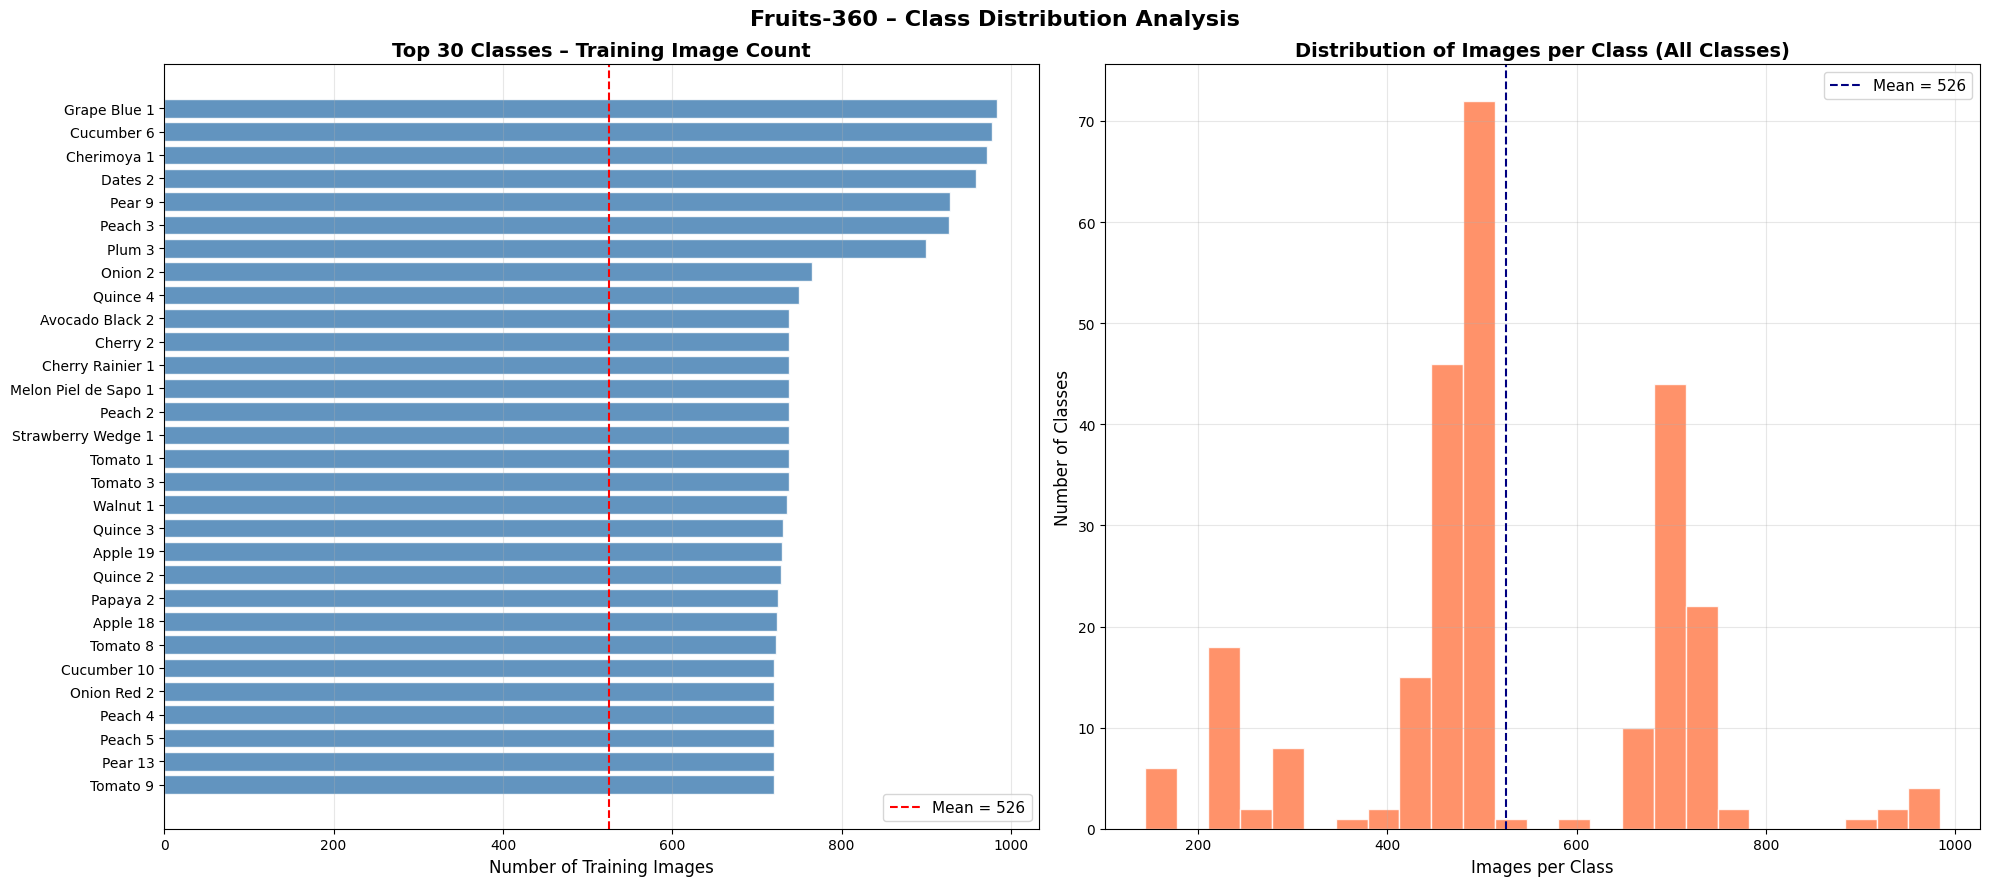

Saved: class_distribution.png


In [5]:
top30 = dist_df.nlargest(30, 'Train')

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Left: Top-30 bar chart
bars = axes[0].barh(top30['Class'], top30['Train'],
                    color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Number of Training Images', fontsize=12)
axes[0].set_title('Top 30 Classes – Training Image Count', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].axvline(dist_df['Train'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean = {dist_df["Train"].mean():.0f}')
axes[0].legend(fontsize=11)
axes[0].grid(axis='x', alpha=0.3)

# Right: Histogram of all class sizes
axes[1].hist(dist_df['Train'], bins=25, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Images per Class', fontsize=12)
axes[1].set_ylabel('Number of Classes', fontsize=12)
axes[1].set_title('Distribution of Images per Class (All Classes)', fontsize=14, fontweight='bold')
axes[1].axvline(dist_df['Train'].mean(), color='navy', linestyle='--', linewidth=1.5,
                label=f'Mean = {dist_df["Train"].mean():.0f}')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Fruits-360 – Class Distribution Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

# Sample Images from Dataset

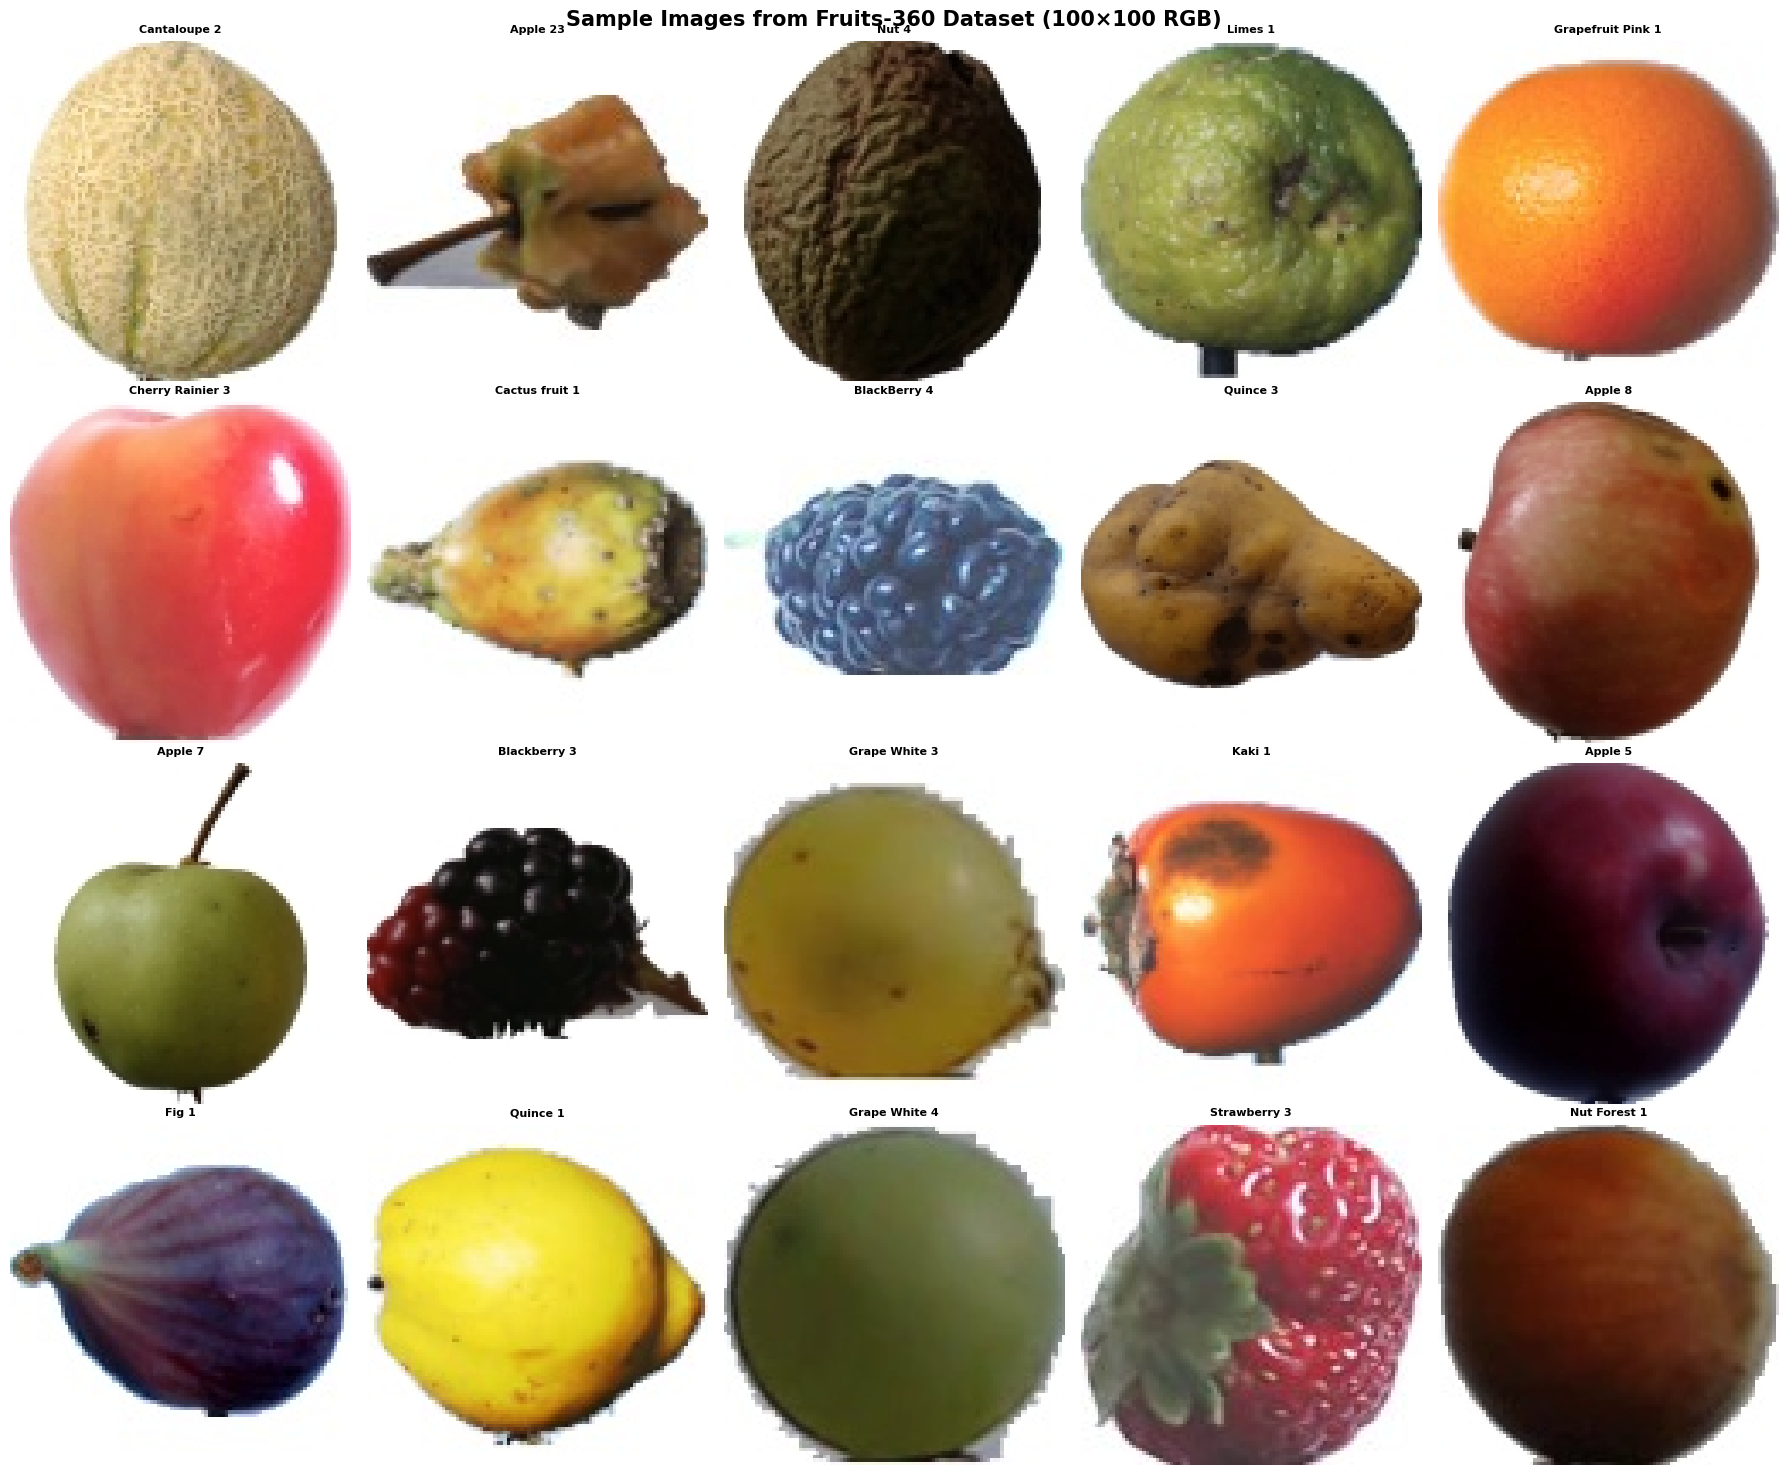

Saved: sample_images.png


In [6]:
sample_classes = random.sample(train_classes, min(20, len(train_classes)))

fig, axes = plt.subplots(4, 5, figsize=(18, 15))
axes = axes.flatten()

for i, cls in enumerate(sample_classes):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_file = random.choice(os.listdir(cls_path))
    img = mpimg.imread(os.path.join(cls_path, img_file))
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=8, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Sample Images from Fruits-360 Dataset (100×100 RGB)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sample_images.png")

# Pixel Intensity Analysis

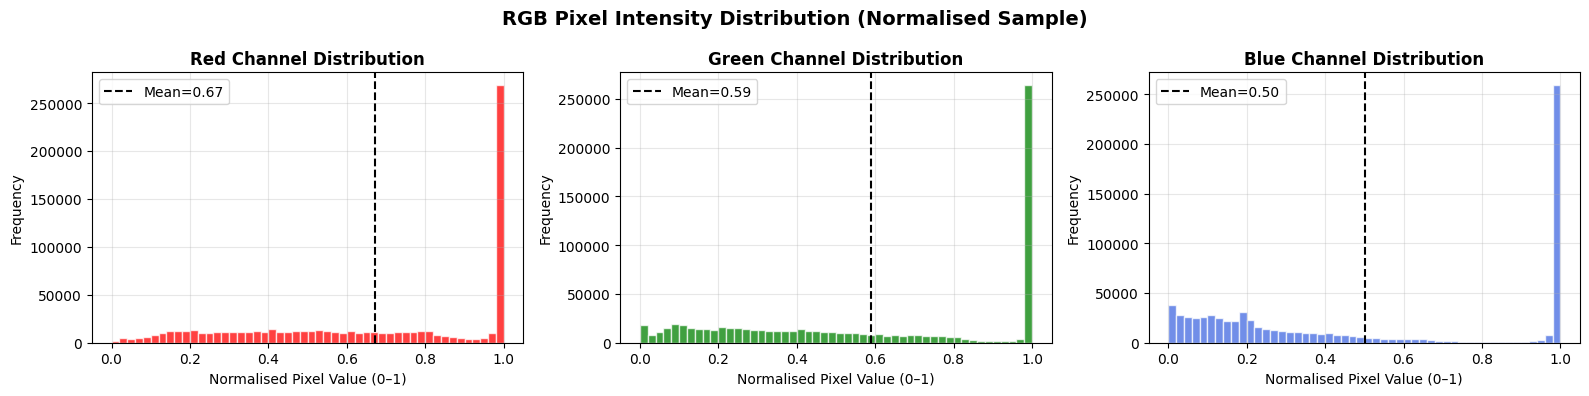

Mean pixel value (R, G, B) : [0.6706045  0.58897573 0.50279302]
Std  pixel value (R, G, B) : [0.31640912 0.35858777 0.39955974]

The large spike near 1.0 in all channels confirms the white background (pixel=255/255=1.0)


In [7]:
# Load a random sample of images and analyse pixel statistics
pixel_samples = []
for cls in random.sample(train_classes, min(15, len(train_classes))):
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in random.sample(os.listdir(cls_path), min(5, len(os.listdir(cls_path)))):
        img = np.array(Image.open(os.path.join(cls_path, fname)).resize(IMG_SIZE)) / 255.0
        if img.ndim == 3 and img.shape[2] == 3:  # ensure RGB
            pixel_samples.append(img)

pixel_arr = np.array(pixel_samples)  # shape: (N, 100, 100, 3)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
channels = ['Red', 'Green', 'Blue']
colors   = ['red', 'green', 'royalblue']

for ch, (ax, name, col) in enumerate(zip(axes, channels, colors)):
    ax.hist(pixel_arr[:, :, :, ch].flatten(), bins=50, color=col, alpha=0.75, edgecolor='white')
    ax.set_title(f'{name} Channel Distribution', fontweight='bold', fontsize=12)
    ax.set_xlabel('Normalised Pixel Value (0–1)')
    ax.set_ylabel('Frequency')
    ax.axvline(pixel_arr[:, :, :, ch].mean(), color='black', linestyle='--',
               label=f'Mean={pixel_arr[:,:,:,ch].mean():.2f}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('RGB Pixel Intensity Distribution (Normalised Sample)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

mean_rgb = pixel_arr.mean(axis=(0, 1, 2))
std_rgb  = pixel_arr.std(axis=(0, 1, 2))
print(f"Mean pixel value (R, G, B) : {mean_rgb}")
print(f"Std  pixel value (R, G, B) : {std_rgb}")
print("\nThe large spike near 1.0 in all channels confirms the white background (pixel=255/255=1.0)")

# Data Generators: Preprocessing & Augmentation

In [8]:
# Training Generator (augmentation + validation split) 
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=VAL_SPLIT
)

# Test Generator (rescale only no augmentation) 
test_datagen = ImageDataGenerator(rescale=1./255)

# Train Generator 
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

# Validation Generator 
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

# Test Generator 
test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False 
)

NUM_CLASSES  = train_gen.num_classes
CLASS_LABELS = list(train_gen.class_indices.keys())

print(f"  Training samples   : {train_gen.samples:,}")
print(f"  Validation samples : {val_gen.samples:,}")
print(f"  Test samples       : {test_gen.samples:,}")
print(f"  Number of classes  : {NUM_CLASSES}")
print(f"  Input shape        : {IMG_SIZE[0]}×{IMG_SIZE[1]}×3")

Found 108144 images belonging to 257 classes.
Found 26927 images belonging to 257 classes.
Found 45008 images belonging to 257 classes.
  Training samples   : 108,144
  Validation samples : 26,927
  Test samples       : 45,008
  Number of classes  : 257
  Input shape        : 100×100×3


# Visualise Augmented Images

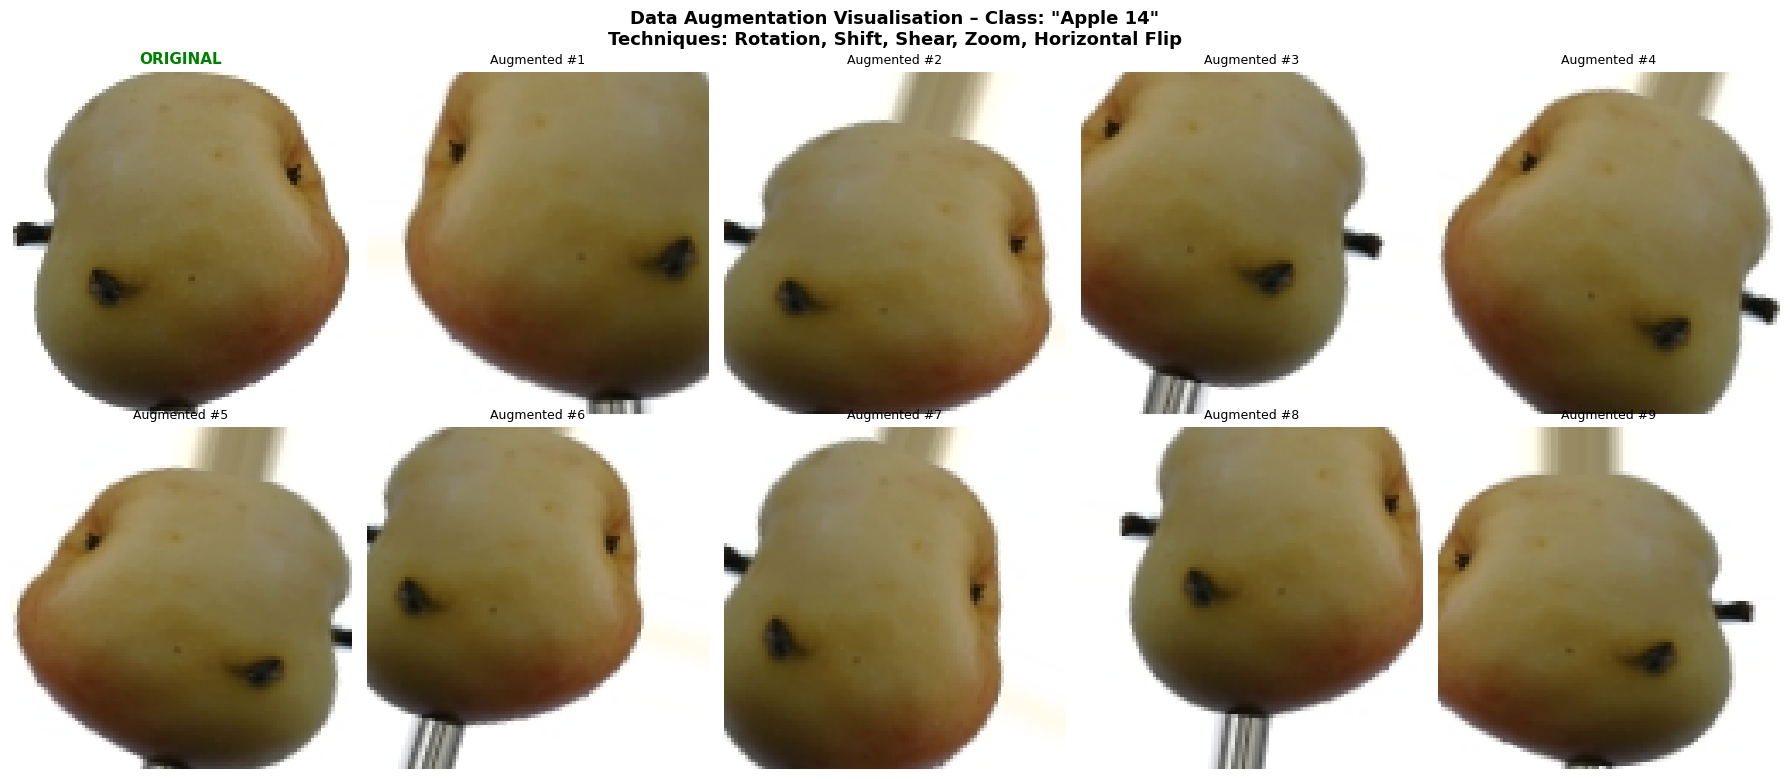

Saved: augmentation_examples.png


In [9]:
# Show original vs augmented versions of one image
sample_cls = train_classes[5]  # pick a class
cls_path   = os.path.join(TRAIN_DIR, sample_cls)
orig_path  = os.path.join(cls_path, os.listdir(cls_path)[0])
original   = np.array(Image.open(orig_path).resize(IMG_SIZE))

aug_gen_vis = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True
)
aug_iter = aug_gen_vis.flow(original[np.newaxis, ...], batch_size=1, seed=SEED)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

axes[0].imshow(original)
axes[0].set_title('ORIGINAL', fontweight='bold', color='green', fontsize=11)
axes[0].axis('off')

for i in range(1, 10):
    aug_img = next(aug_iter)[0].astype(np.uint8)
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmented #{i}', fontsize=9)
    axes[i].axis('off')

plt.suptitle(f'Data Augmentation Visualisation – Class: "{sample_cls}"\n'
             f'Techniques: Rotation, Shift, Shear, Zoom, Horizontal Flip',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: augmentation_examples.png")

# PART A – SECTION 2: Baseline CNN Model

# Build Baseline CNN Model

In [11]:
def build_baseline_cnn(input_shape, num_classes):
    model = models.Sequential(name='Baseline_CNN')

    # Block 1: Conv(32, 3×3) + MaxPool 
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            input_shape=input_shape, name='conv1'))
    model.add(layers.MaxPooling2D((2, 2), name='pool1'))

    # Block 2: Conv(64, 3×3) + MaxPool 
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'))
    model.add(layers.MaxPooling2D((2, 2), name='pool2'))

    # Block 3: Conv(128, 3×3) + MaxPool 
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'))
    model.add(layers.MaxPooling2D((2, 2), name='pool3'))

    # Flatten 
    model.add(layers.Flatten(name='flatten'))

    # FCN Layer 1 
    model.add(layers.Dense(256, activation='relu', name='fc1'))
    model.add(layers.Dropout(0.4, name='dropout1'))

    # FCN Layer 2 
    model.add(layers.Dense(128, activation='relu', name='fc2'))
    model.add(layers.Dropout(0.3, name='dropout2'))

    # FCN Layer 3 (Output) 
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))

    # Compile 
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

INPUT_SHAPE    = (IMG_SIZE[0], IMG_SIZE[1], 3)
baseline_model = build_baseline_cnn(INPUT_SHAPE, NUM_CLASSES)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 257)            │        33,153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,878,145 (18.61 MB)

 Trainable params: 4,878,145 (18.61 MB)

 Non-trainable params: 0 (0.00 B)

# Train Baseline CNN

In [14]:
callbacks_base = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Training Baseline CNN...")
print(f"Epochs: {EPOCHS_BASE} | Batch Size: {BATCH_SIZE} | Optimizer: Adam (lr=1e-3)")
t_start = time.time()

history_base = baseline_model.fit(
    train_gen,
    epochs=EPOCHS_BASE,
    validation_data=val_gen,
    callbacks=callbacks_base,
    verbose=1
)

base_train_time = time.time() - t_start
print(f"\nBaseline CNN training time: {base_train_time/60:.2f} minutes")

Training Baseline CNN...
Epochs: 10 | Batch Size: 64 | Optimizer: Adam (lr=1e-3)
Epoch 1/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 1263s 747ms/step - accuracy: 0.1346 - loss: 3.7967 - val_accuracy: 0.7229 - val_loss: 1.0064 - learning_rate: 0.0010
Epoch 2/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 580s 343ms/step - accuracy: 0.5746 - loss: 1.3064 - val_accuracy: 0.8155 - val_loss: 0.5701 - learning_rate: 0.0010
Epoch 3/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 525s 311ms/step - accuracy: 0.7010 - loss: 0.8891 - val_accuracy: 0.8670 - val_loss: 0.4026 - learning_rate: 0.0010
Epoch 4/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 487s 288ms/step - accuracy: 0.7612 - loss: 0.7025 - val_accuracy: 0.8806 - val_loss: 0.3490 - learning_rate: 0.0010
Epoch 5/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 491s 291ms/step - accuracy: 0.8010 - loss: 0.5836 - val_accuracy: 0.9091 - val_loss: 0.2926 - learning_rate: 0.0010
Epoch 6/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 499s 296ms/step - accuracy: 0.8203 - loss: 0.5177 - val_accuracy: 0.9086 - val_loss: 0

# Baseline Training Curves

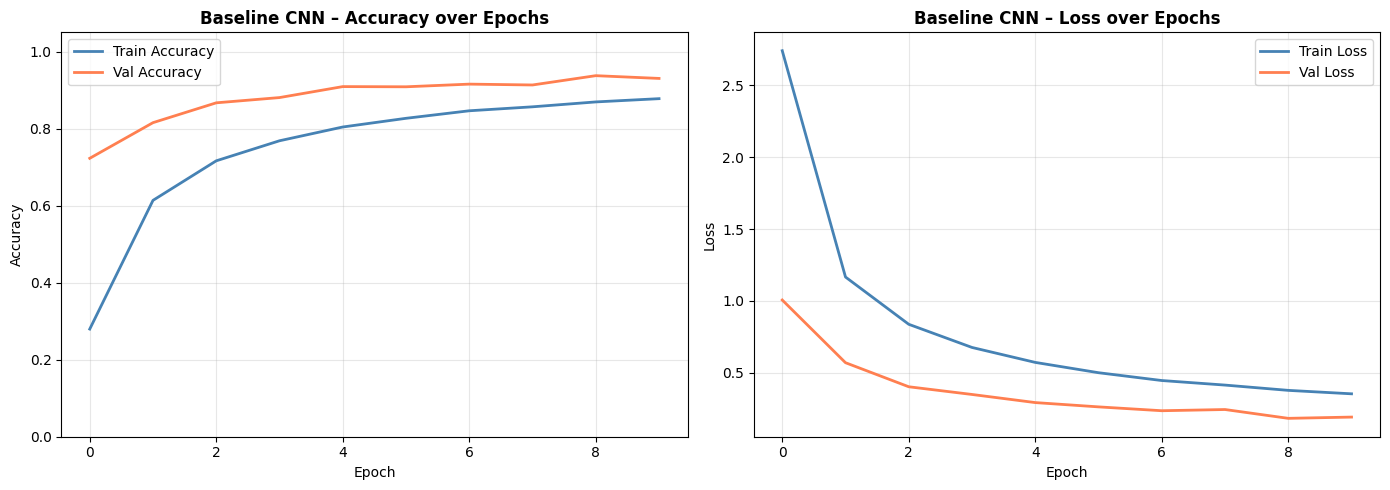

Saved: baseline_training_curves.png

Best validation accuracy : 0.9375 at epoch 9


In [15]:
def plot_history(history, model_name, save_name):
    """Plot training and validation accuracy and loss over epochs."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    ax1.plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue', lw=2)
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   color='coral',     lw=2)
    ax1.set_title(f'{model_name} – Accuracy over Epochs', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(fontsize=10); ax1.grid(alpha=0.3)
    ax1.set_ylim(0, 1.05)

    # Loss
    ax2.plot(history.history['loss'],     label='Train Loss', color='steelblue', lw=2)
    ax2.plot(history.history['val_loss'], label='Val Loss',   color='coral',     lw=2)
    ax2.set_title(f'{model_name} – Loss over Epochs', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(fontsize=10); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_name}")

plot_history(history_base, 'Baseline CNN', 'baseline_training_curves.png')

# Final epoch stats
best_val_acc = max(history_base.history['val_accuracy'])
best_epoch   = history_base.history['val_accuracy'].index(best_val_acc) + 1
print(f"\nBest validation accuracy : {best_val_acc:.4f} at epoch {best_epoch}")

# Evaluate Baseline CNN

In [16]:
def evaluate_model(model, gen, model_name):
    gen.reset()
    y_pred_prob = model.predict(gen, verbose=1)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = gen.classes

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"  {model_name} – Evaluation on Test Set")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}  (weighted avg)")
    print(f"  Recall    : {rec:.4f}  (weighted avg)")
    print(f"  F1-Score  : {f1:.4f}  (weighted avg)")

    return {'model': model_name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'y_pred': y_pred, 'y_true': y_true}

base_metrics = evaluate_model(baseline_model, test_gen, 'Baseline CNN')

# Full classification report (per class)
print("\nFull Classification Report:")
print(classification_report(
    base_metrics['y_true'], base_metrics['y_pred'],
    target_names=CLASS_LABELS, zero_division=0
))

704/704 ━━━━━━━━━━━━━━━━━━━━ 332s 472ms/step
  Baseline CNN – Evaluation on Test Set
  Accuracy  : 0.9510  (95.10%)
  Precision : 0.9556  (weighted avg)
  Recall    : 0.9510  (weighted avg)
  F1-Score  : 0.9490  (weighted avg)

Full Classification Report:
                        precision    recall  f1-score   support

             Almonds 1       1.00      1.00      1.00        77
              Apple 10       1.00      0.90      0.95       231
              Apple 11       1.00      1.00      1.00       142
              Apple 12       0.97      0.88      0.93       154
              Apple 13       1.00      1.00      1.00       235
              Apple 14       1.00      1.00      1.00       154
              Apple 17       0.94      0.91      0.93       201
              Apple 18       1.00      0.95      0.98       240
              Apple 19       1.00      1.00      1.00       241
              Apple 20       1.00      1.00      1.00       234
              Apple 21       1.00      

#  Confusion Matrix (Baseline CNN)

Saved: baseline_cm.png


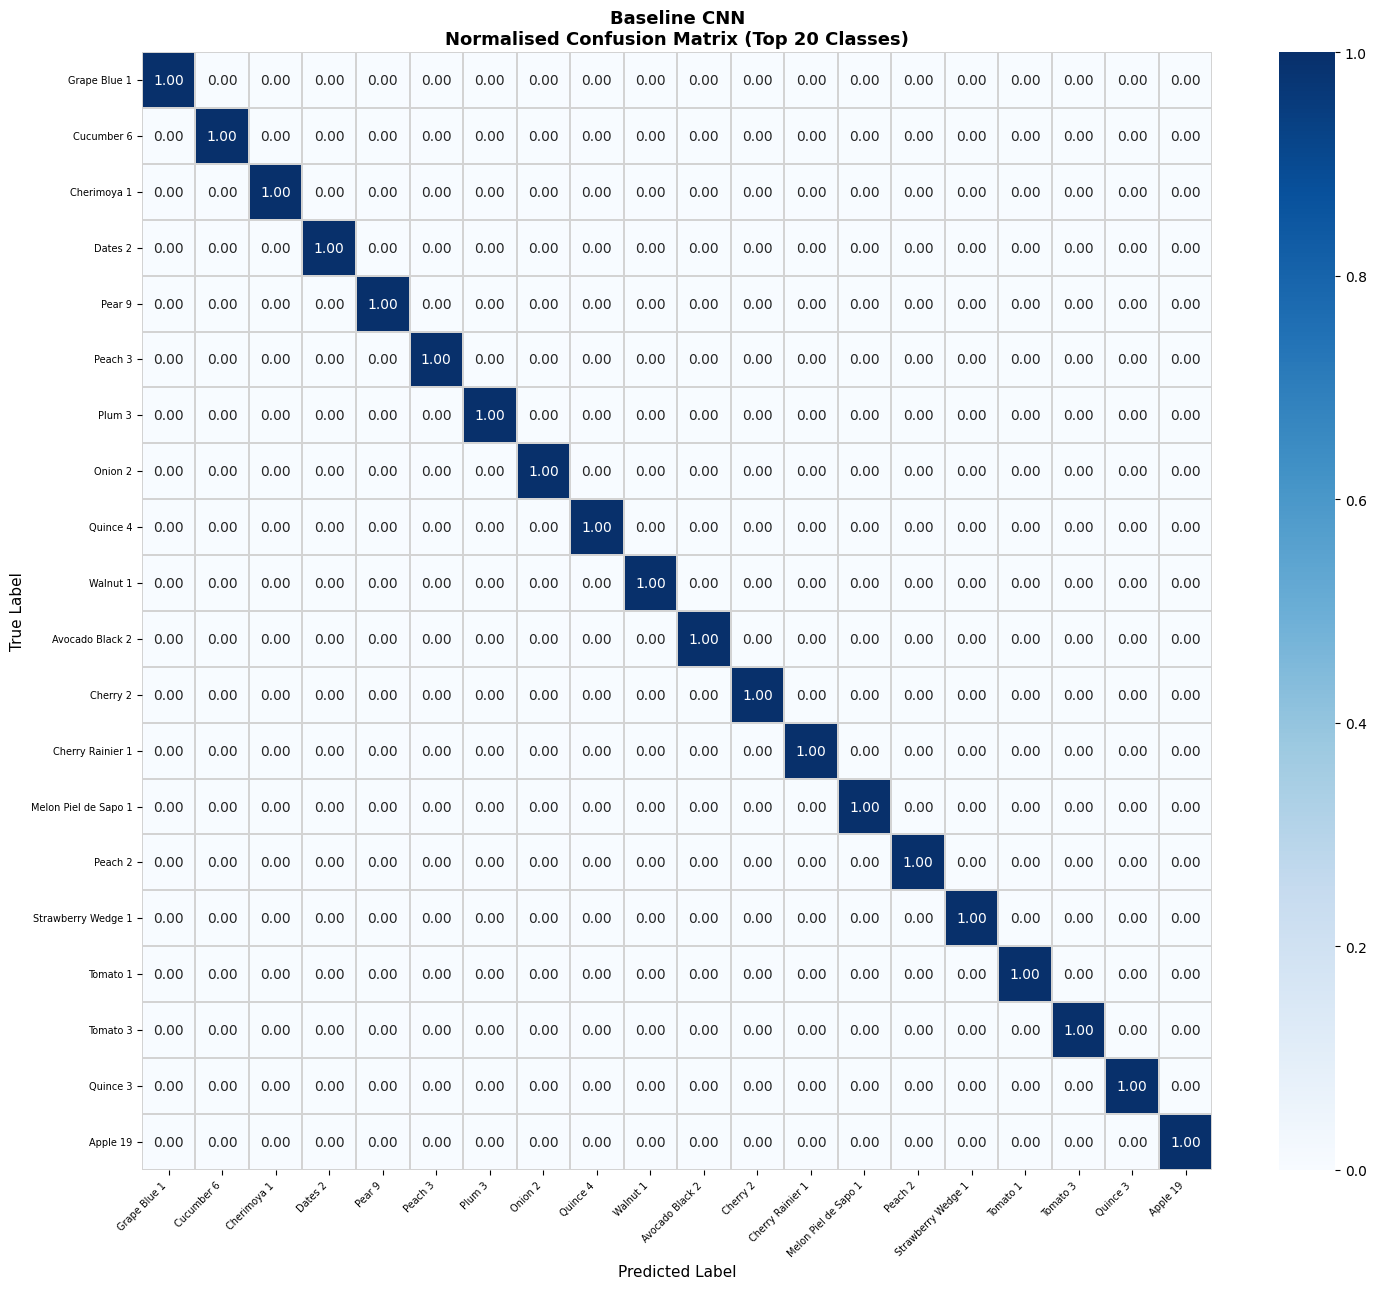

In [17]:
def plot_confusion_matrix_top(y_true, y_pred, class_labels, model_name, top_n=20, save_name=None):
    
    from collections import Counter
    top_indices = [i for i, _ in Counter(y_true).most_common(top_n)]
    mask = np.isin(y_true, top_indices)
    yt = y_true[mask]; yp = y_pred[mask]
    labels = [class_labels[i] for i in top_indices]

    idx_map = {old: new for new, old in enumerate(top_indices)}
    yt_r = np.array([idx_map[v] for v in yt])
    yp_r = np.array([idx_map.get(v, -1) for v in yp])
    valid = yp_r >= 0
    yt_r = yt_r[valid]; yp_r = yp_r[valid]

    cm = confusion_matrix(yt_r, yp_r)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(15, 13))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax,
                linewidths=0.3, linecolor='lightgray')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title(f'{model_name}\nNormalised Confusion Matrix (Top {top_n} Classes)',
                 fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_name}")
    plt.show()

plot_confusion_matrix_top(
    base_metrics['y_true'], base_metrics['y_pred'],
    CLASS_LABELS, 'Baseline CNN',
    top_n=20, save_name='baseline_cm.png'
)

# Inference on Sample Test Images (Baseline CNN)

Saved: baseline_inference.png


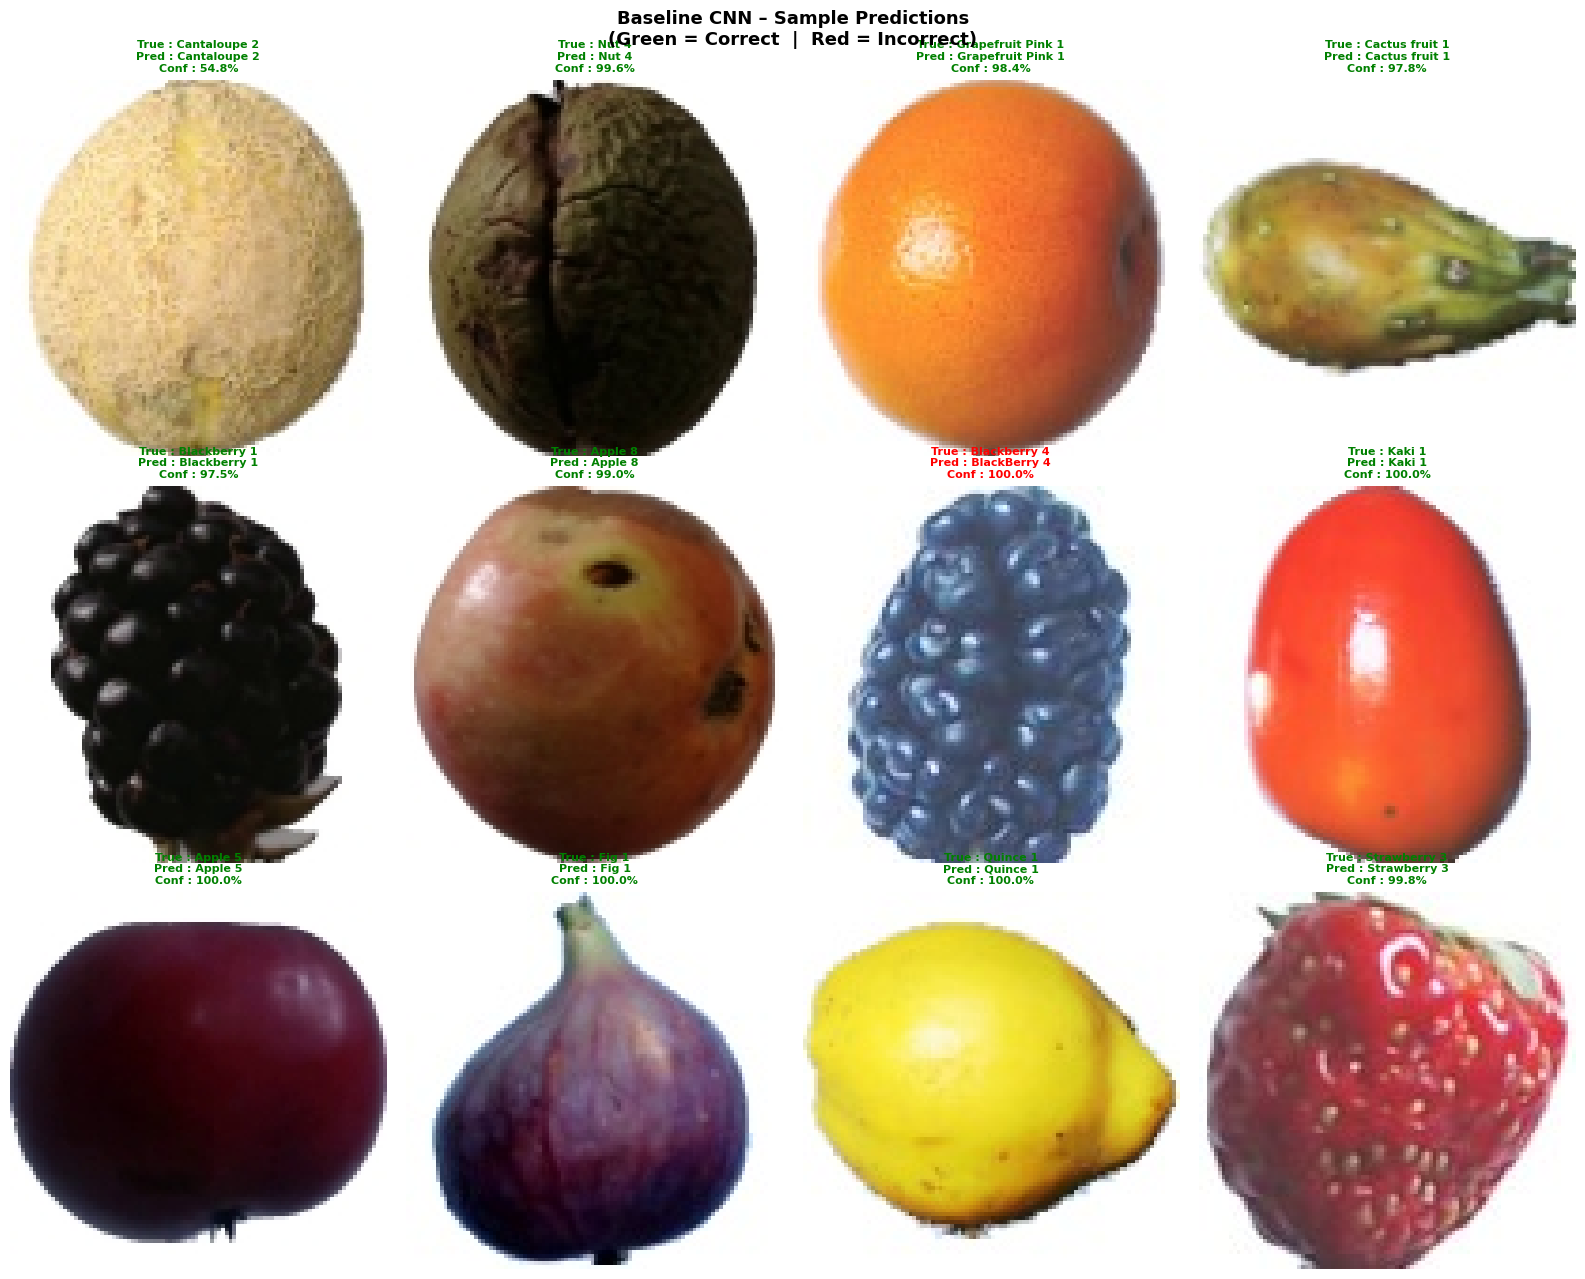

In [18]:
def show_inference(model, test_dir, class_labels, model_name, n=12, save_name=None):
    all_test_classes = sorted(os.listdir(test_dir))
    images, true_lbls = [], []

    random.seed(SEED)
    for _ in range(n):
        cls      = random.choice(all_test_classes)
        cls_path = os.path.join(test_dir, cls)
        img_file = random.choice(os.listdir(cls_path))
        img = np.array(Image.open(os.path.join(cls_path, img_file)).resize(IMG_SIZE)) / 255.0
        images.append(img)
        true_lbls.append(cls)

    batch      = np.array(images)
    preds      = model.predict(batch, verbose=0)
    pred_lbls  = [class_labels[np.argmax(p)] for p in preds]
    confs      = [preds[i][np.argmax(preds[i])] * 100 for i in range(n)]

    fig, axes = plt.subplots(3, 4, figsize=(16, 13))
    axes = axes.flatten()

    for i in range(n):
        axes[i].imshow(images[i])
        correct = pred_lbls[i] == true_lbls[i]
        colour  = 'green' if correct else 'red'
        axes[i].set_title(
            f'True : {true_lbls[i]}\nPred : {pred_lbls[i]}\nConf : {confs[i]:.1f}%',
            fontsize=8, color=colour, fontweight='bold'
        )
        axes[i].axis('off')

    plt.suptitle(f'{model_name} – Sample Predictions\n(Green = Correct  |  Red = Incorrect)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_name}")
    plt.show()

show_inference(baseline_model, TEST_DIR, CLASS_LABELS,
               'Baseline CNN', save_name='baseline_inference.png')

# PART A – SECTION 3: Deeper CNN with Regularisation

# Build Deeper CNN Model

In [19]:
def build_deeper_cnn(input_shape, num_classes, optimizer='adam'):
    
    model = models.Sequential(name=f'Deeper_CNN_{optimizer}')

    # Block 1: Conv(32) + BN + MaxPool 
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same',
                            input_shape=input_shape, name='conv1'))
    model.add(layers.BatchNormalization(name='bn1'))
    model.add(layers.MaxPooling2D((2,2), name='pool1'))
    model.add(layers.Dropout(0.25, name='drop1'))

    #  Block 2: Conv(64) + BN + MaxPool 
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2'))
    model.add(layers.BatchNormalization(name='bn2'))
    model.add(layers.MaxPooling2D((2,2), name='pool2'))
    model.add(layers.Dropout(0.25, name='drop2'))

    # Block 3: Conv(128) + BN + MaxPool 
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv3'))
    model.add(layers.BatchNormalization(name='bn3'))
    model.add(layers.MaxPooling2D((2,2), name='pool3'))
    model.add(layers.Dropout(0.25, name='drop3'))

    # Block 4: Conv(256) + BN 
    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same', name='conv4'))
    model.add(layers.BatchNormalization(name='bn4'))
    model.add(layers.Dropout(0.25, name='drop4'))

    # Block 5: Conv(256) + BN + MaxPool 
    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same', name='conv5'))
    model.add(layers.BatchNormalization(name='bn5'))
    model.add(layers.MaxPooling2D((2,2), name='pool4'))
    model.add(layers.Dropout(0.25, name='drop5'))

    # Block 6: Conv(256) + BN 
    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same', name='conv6'))
    model.add(layers.BatchNormalization(name='bn6'))

    # Global Average Pooling 
    model.add(layers.GlobalAveragePooling2D(name='gap'))

    # FC Layer 1 
    model.add(layers.Dense(512, activation='relu', name='fc1'))
    model.add(layers.Dropout(0.5, name='fc_drop1'))

    # FC Layer 2 
    model.add(layers.Dense(256, activation='relu', name='fc2'))
    model.add(layers.Dropout(0.4, name='fc_drop2'))

    # Output Layer 
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))

    # Compile with chosen optimizer 
    if optimizer == 'adam':
        opt = Adam(learning_rate=1e-3)
    else:  # sgd
        opt = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

    model.compile(optimizer=opt,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Build deeper model with Adam
deeper_model_adam = build_deeper_cnn(INPUT_SHAPE, NUM_CLASSES, optimizer='adam')
deeper_model_adam.summary()

Model: "Deeper_CNN_adam"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 100, 100, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 50, 50, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 25, 25, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 12, 12, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 12, 12, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop5 (Dropout)                 │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv6 (Conv2D)                  │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn6 (BatchNormalization)        │ (None, 6, 6, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_drop1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,32

 Total params: 1,901,505 (7.25 MB)

 Trainable params: 1,899,521 (7.25 MB)

 Non-trainable params: 1,984 (7.75 KB)

#  Train Deeper CNN (Adam Optimizer)

In [20]:
callbacks_deep = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1)
]

print("Training Deeper CNN with Adam optimizer...")
print(f"Epochs: {EPOCHS_DEEP} | Batch Size: {BATCH_SIZE} | Optimizer: Adam (lr=1e-3)")
t_start = time.time()

history_deep_adam = deeper_model_adam.fit(
    train_gen,
    epochs=EPOCHS_DEEP,
    validation_data=val_gen,
    callbacks=callbacks_deep,
    verbose=1
)

deep_adam_time = time.time() - t_start
print(f"\nDeeeper CNN (Adam) training time: {deep_adam_time/60:.2f} minutes")

Training Deeper CNN with Adam optimizer...
Epochs: 15 | Batch Size: 64 | Optimizer: Adam (lr=1e-3)
Epoch 1/15
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 550s 318ms/step - accuracy: 0.2659 - loss: 2.9651 - val_accuracy: 0.3596 - val_loss: 2.5597 - learning_rate: 0.0010
Epoch 2/15
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 435s 258ms/step - accuracy: 0.7093 - loss: 0.8649 - val_accuracy: 0.7128 - val_loss: 0.9743 - learning_rate: 0.0010
Epoch 3/15
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 423s 251ms/step - accuracy: 0.8245 - loss: 0.5113 - val_accuracy: 0.7454 - val_loss: 0.8685 - learning_rate: 0.0010
Epoch 4/15
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 422s 250ms/step - accuracy: 0.8708 - loss: 0.3708 - val_accuracy: 0.8417 - val_loss: 0.4896 - learning_rate: 0.0010
Epoch 5/15
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 414s 245ms/step - accuracy: 0.8975 - loss: 0.2906 - val_accuracy: 0.8035 - val_loss: 0.6816 - learning_rate: 0.0010
Epoch 6/15
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 420s 249ms/step - accuracy: 0.9154 - loss: 0.2398 - val_accuracy: 0.8

# Train Deeper CNN (SGD Optimizer)

In [21]:
# Build a fresh copy of the deeper model with SGD
deeper_model_sgd = build_deeper_cnn(INPUT_SHAPE, NUM_CLASSES, optimizer='sgd')

print("Training Deeper CNN with SGD optimizer...")
print(f"Epochs: {EPOCHS_DEEP} | Batch Size: {BATCH_SIZE} | Optimizer: SGD (lr=0.01, momentum=0.9, Nesterov=True)")
t_start = time.time()

history_deep_sgd = deeper_model_sgd.fit(
    train_gen,
    epochs=EPOCHS_DEEP,
    validation_data=val_gen,
    callbacks=callbacks_deep,
    verbose=1
)

deep_sgd_time = time.time() - t_start
print(f"\nDeeper CNN (SGD) training time: {deep_sgd_time/60:.2f} minutes")

Training Deeper CNN with SGD optimizer...
Epochs: 15 | Batch Size: 64 | Optimizer: SGD (lr=0.01, momentum=0.9, Nesterov=True)
------------------------------------------------------------
Epoch 1/15
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 453s 262ms/step - accuracy: 0.2105 - loss: 3.3957 - val_accuracy: 0.2015 - val_loss: 3.8700 - learning_rate: 0.0100
Epoch 2/15
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 428s 253ms/step - accuracy: 0.6369 - loss: 1.1117 - val_accuracy: 0.4993 - val_loss: 1.7854 - learning_rate: 0.0100
Epoch 3/15
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 434s 257ms/step - accuracy: 0.7703 - loss: 0.6782 - val_accuracy: 0.7401 - val_loss: 0.8939 - learning_rate: 0.0100
Epoch 4/15
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 450s 266ms/step - accuracy: 0.8409 - loss: 0.4614 - val_accuracy: 0.7440 - val_loss: 0.8898 - learning_rate: 0.0100
Epoch 5/15
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 441s 261ms/step - accuracy: 0.8811 - loss: 0.3414 - val_accuracy: 0.8396 - val_loss: 0.5411 - learning_rate: 0.0100
Epoch 6/15
1690/1690 ━━

# Evaluate Both Deeper Models

704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 121ms/step
  Deeper CNN (Adam) – Evaluation on Test Set
  Accuracy  : 0.9426  (94.26%)
  Precision : 0.9505  (weighted avg)
  Recall    : 0.9426  (weighted avg)
  F1-Score  : 0.9396  (weighted avg)
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 63ms/step
  Deeper CNN (SGD) – Evaluation on Test Set
  Accuracy  : 0.9497  (94.97%)
  Precision : 0.9539  (weighted avg)
  Recall    : 0.9497  (weighted avg)
  F1-Score  : 0.9466  (weighted avg)
Saved: deeper_adam_cm.png


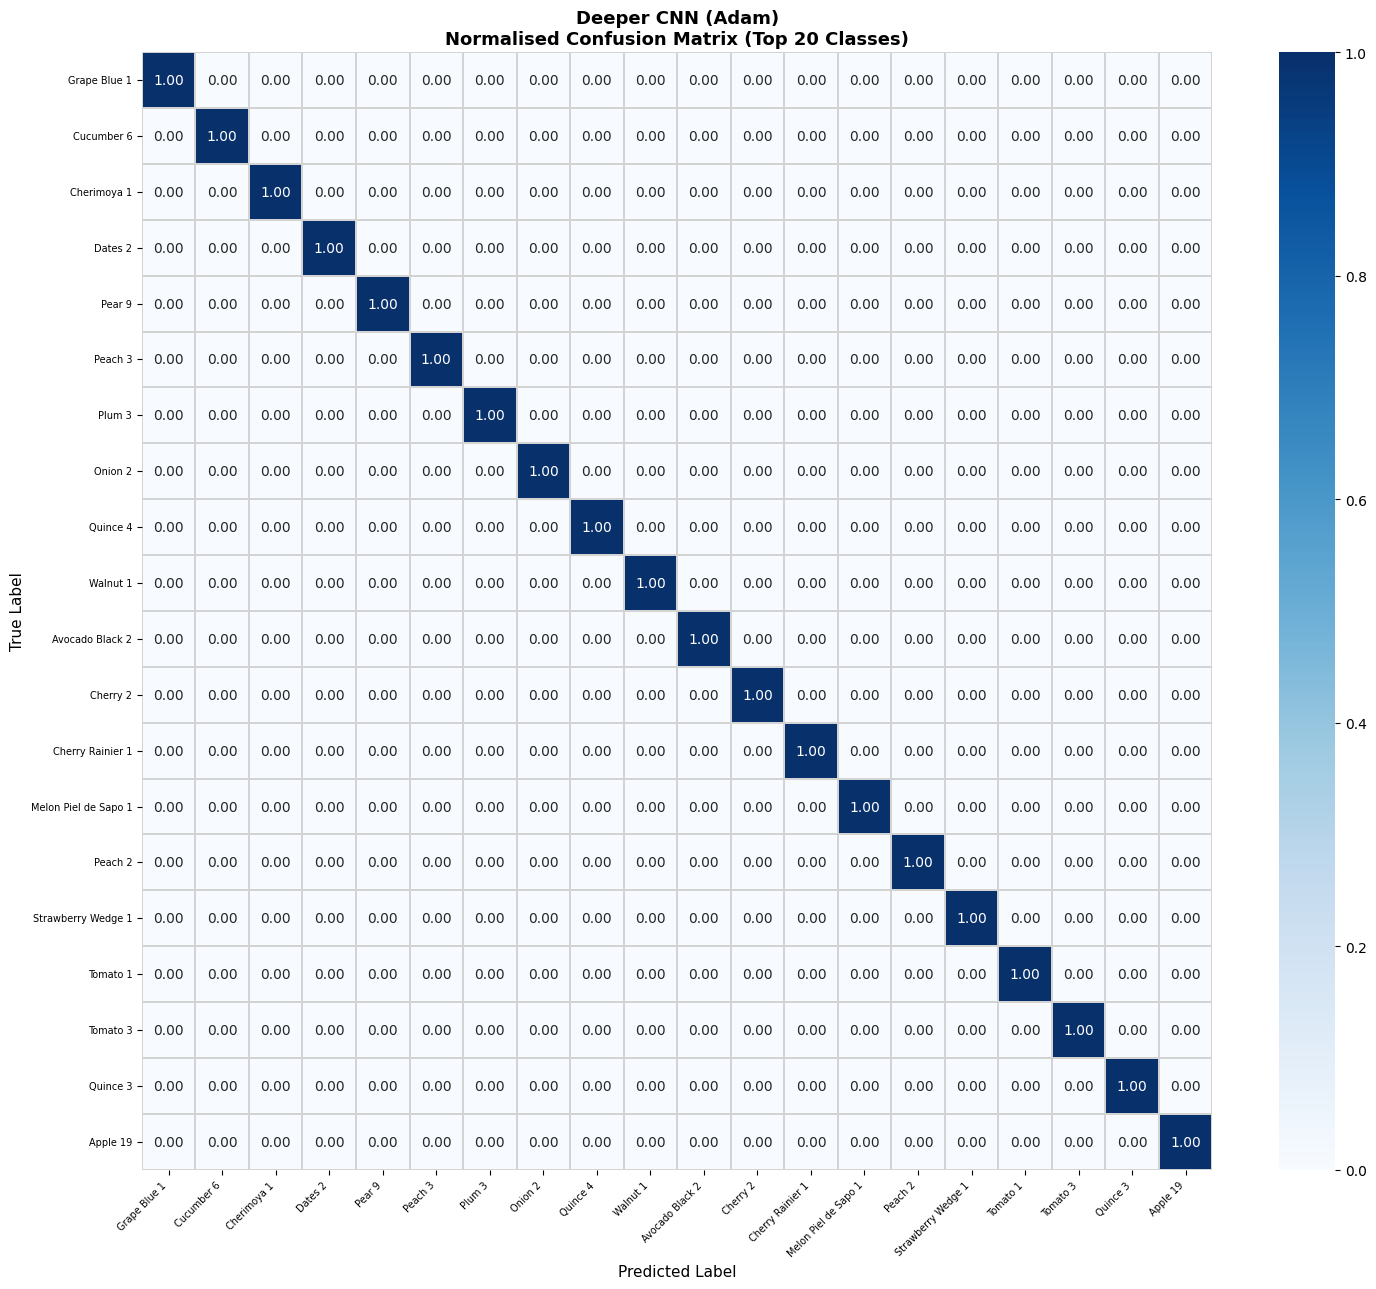

Saved: deeper_sgd_cm.png


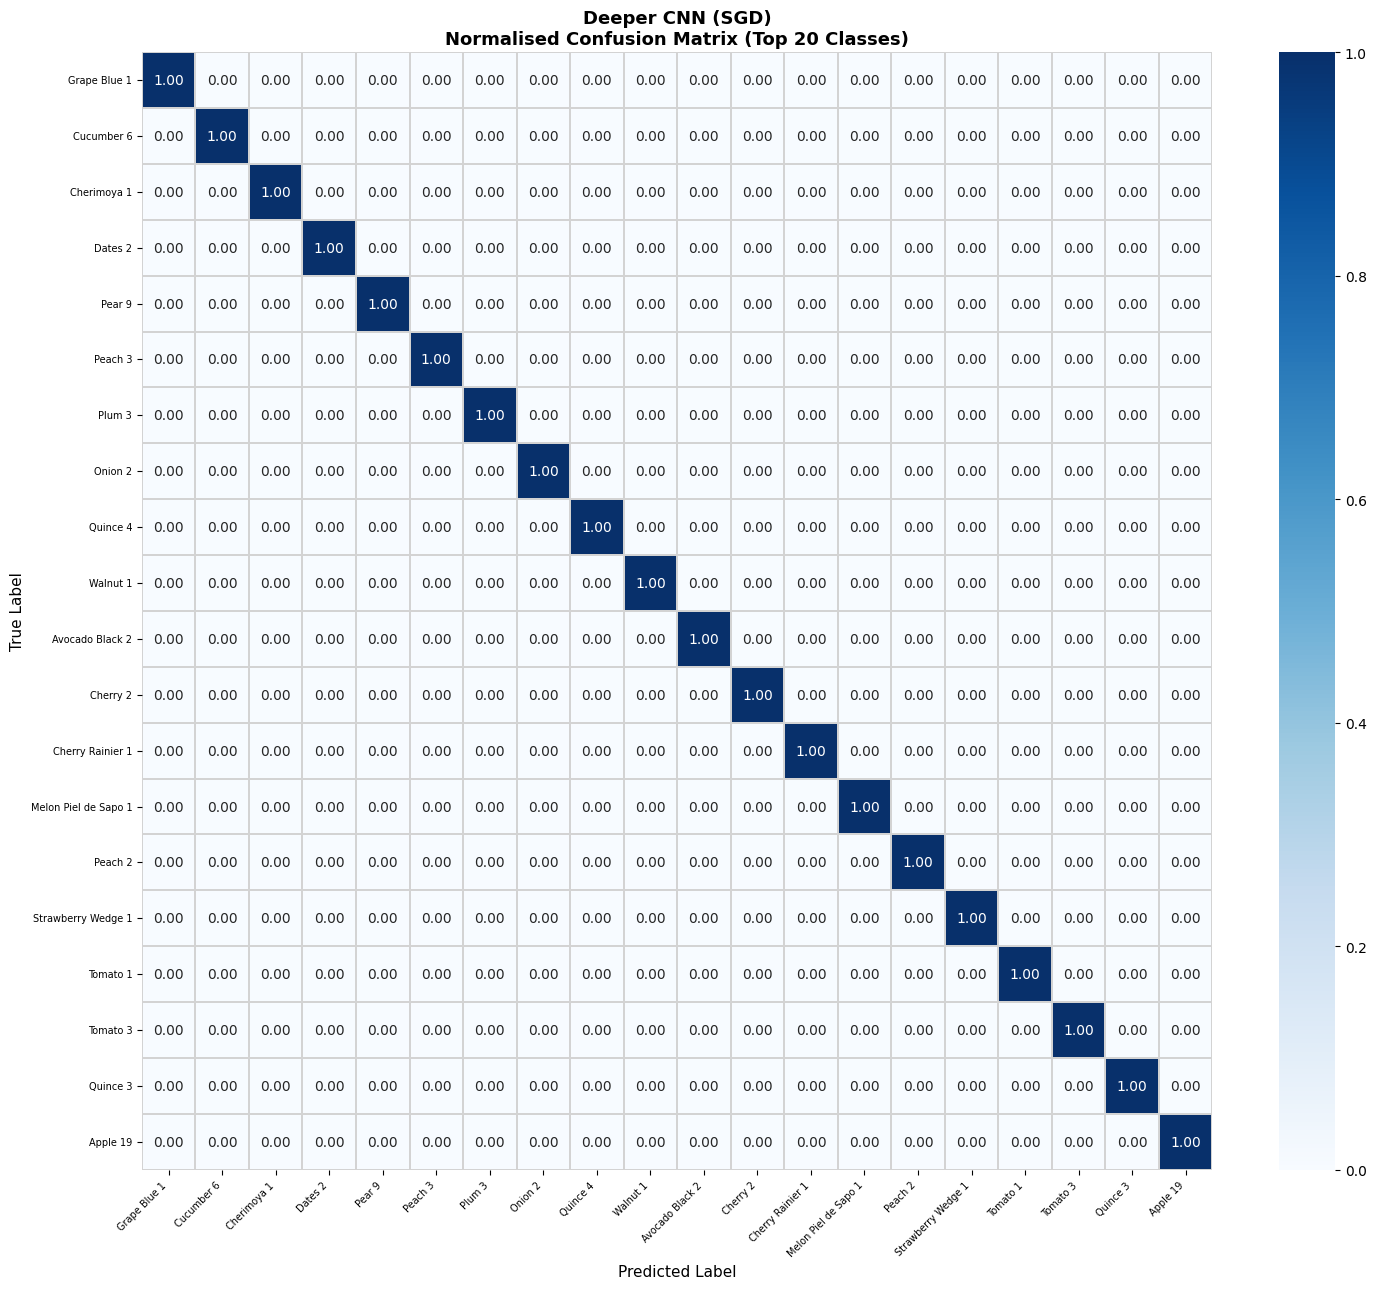

Saved: deeper_adam_inference.png


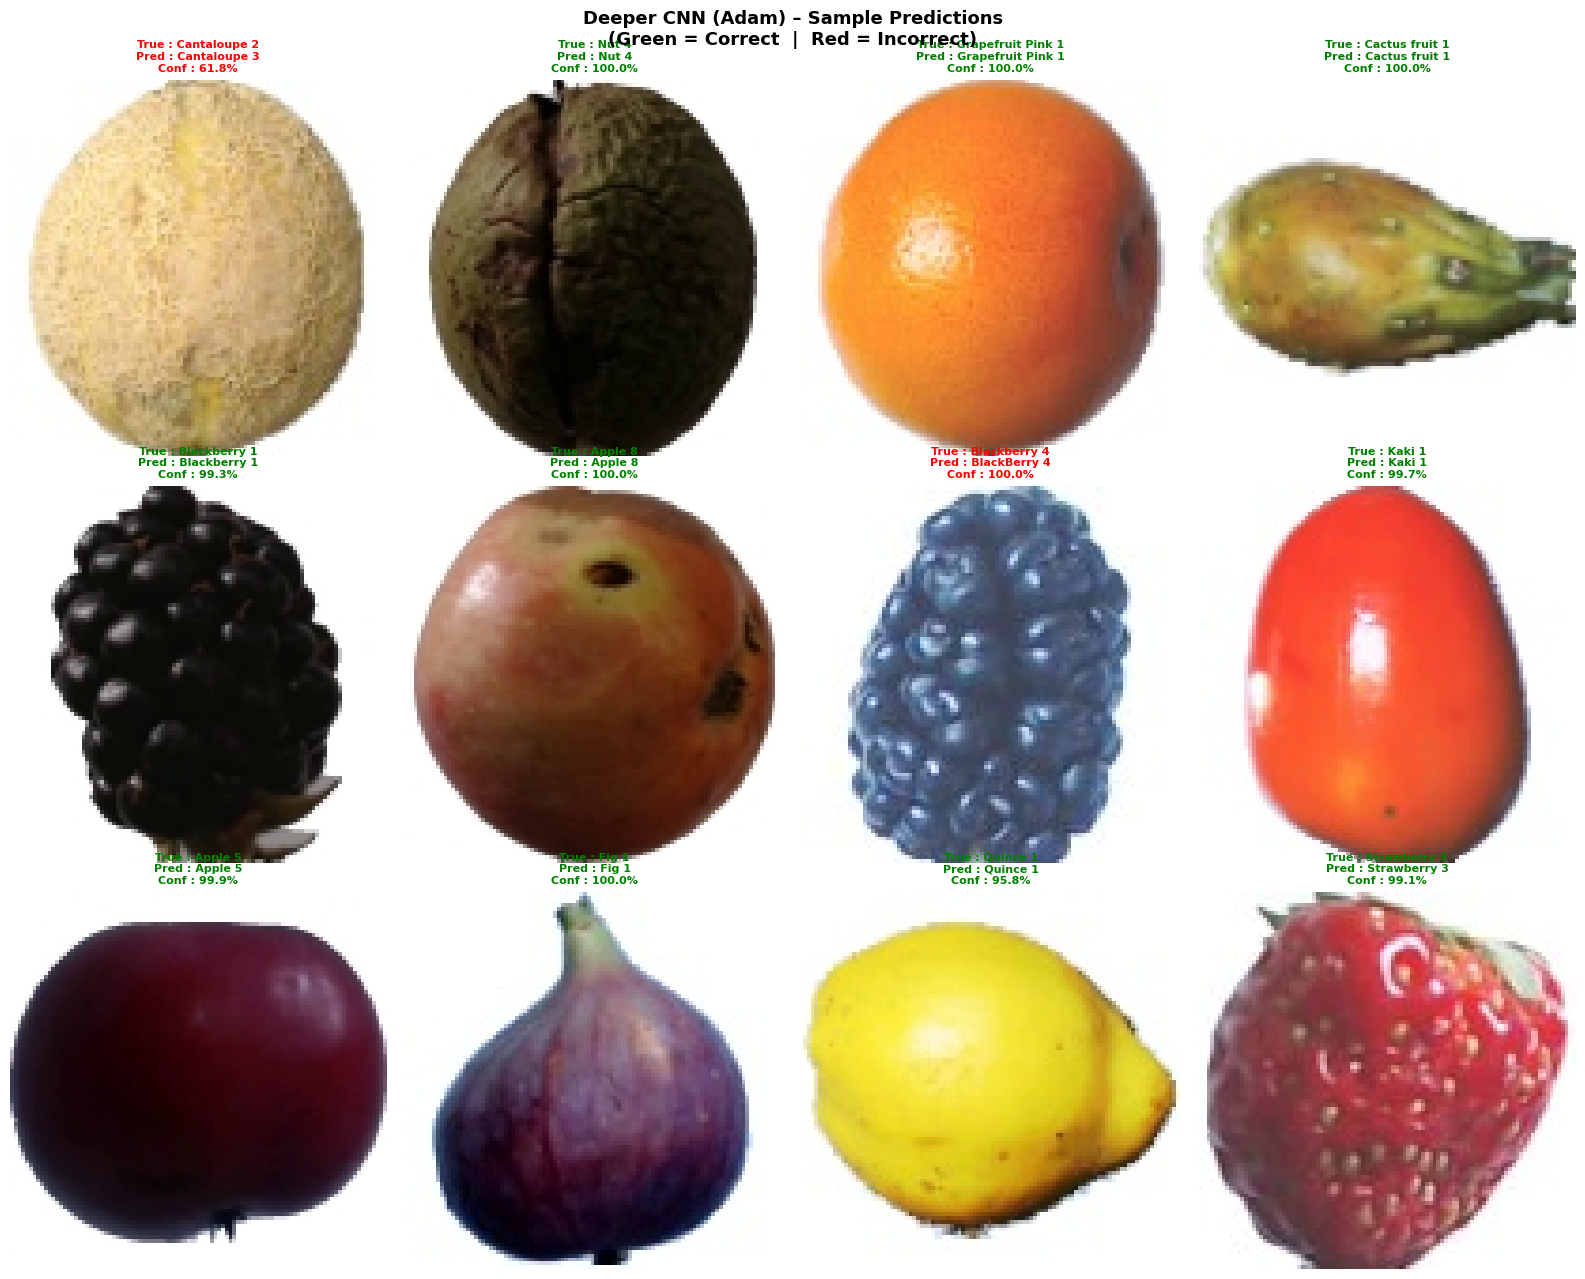

In [22]:
deep_adam_metrics = evaluate_model(deeper_model_adam, test_gen, 'Deeper CNN (Adam)')
deep_sgd_metrics  = evaluate_model(deeper_model_sgd,  test_gen, 'Deeper CNN (SGD)')

# Confusion matrices
plot_confusion_matrix_top(
    deep_adam_metrics['y_true'], deep_adam_metrics['y_pred'],
    CLASS_LABELS, 'Deeper CNN (Adam)', top_n=20, save_name='deeper_adam_cm.png'
)

plot_confusion_matrix_top(
    deep_sgd_metrics['y_true'], deep_sgd_metrics['y_pred'],
    CLASS_LABELS, 'Deeper CNN (SGD)', top_n=20, save_name='deeper_sgd_cm.png'
)

# Inference
show_inference(deeper_model_adam, TEST_DIR, CLASS_LABELS,
               'Deeper CNN (Adam)', save_name='deeper_adam_inference.png')

#  Optimizer Comparison: Adam vs SGD

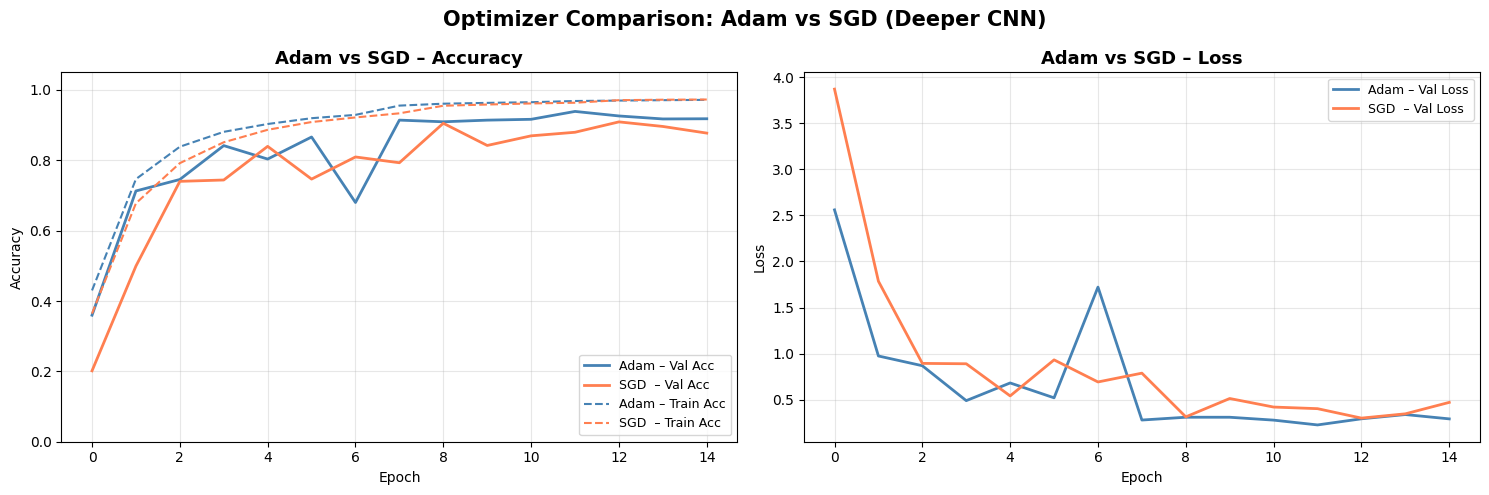

Saved: optimizer_comparison.png

Adam – Best Val Accuracy : 0.9389
SGD  – Best Val Accuracy : 0.9092


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy comparison
axes[0].plot(history_deep_adam.history['val_accuracy'], label='Adam – Val Acc',
             color='steelblue', lw=2)
axes[0].plot(history_deep_sgd.history['val_accuracy'],  label='SGD  – Val Acc',
             color='coral',     lw=2)
axes[0].plot(history_deep_adam.history['accuracy'], label='Adam – Train Acc',
             color='steelblue', lw=1.5, linestyle='--')
axes[0].plot(history_deep_sgd.history['accuracy'],  label='SGD  – Train Acc',
             color='coral',     lw=1.5, linestyle='--')
axes[0].set_title('Adam vs SGD – Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1.05)

# Loss comparison
axes[1].plot(history_deep_adam.history['val_loss'], label='Adam – Val Loss',
             color='steelblue', lw=2)
axes[1].plot(history_deep_sgd.history['val_loss'],  label='SGD  – Val Loss',
             color='coral',     lw=2)
axes[1].set_title('Adam vs SGD – Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('Optimizer Comparison: Adam vs SGD (Deeper CNN)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: optimizer_comparison.png")

print(f"\nAdam – Best Val Accuracy : {max(history_deep_adam.history['val_accuracy']):.4f}")
print(f"SGD  – Best Val Accuracy : {max(history_deep_sgd.history['val_accuracy']):.4f}")

# PART A – SECTION 4: Ablation Study

# Ablation Study: Remove Dropout

In [24]:
def build_ablation_no_dropout(input_shape, num_classes):
    
    model = models.Sequential(name='Ablation_No_Dropout')

    # 6 Conv blocks : identical to deeper model but NO Dropout
    model.add(layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(64,  (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())

    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(512, activation='relu'))
    # NO DROPOUT HERE
    model.add(layers.Dense(256, activation='relu'))
    # NO DROPOUT HERE
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

ablation_model = build_ablation_no_dropout(INPUT_SHAPE, NUM_CLASSES)

print("Training Ablation Model (No Dropout)...")
t_start = time.time()

history_ablation = ablation_model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks_deep,
    verbose=1
)

ablation_time = time.time() - t_start
ablation_metrics = evaluate_model(ablation_model, test_gen, 'Ablation (No Dropout)')
print(f"\nAblation training time: {ablation_time/60:.2f} minutes")

Training Ablation Model (No Dropout)...
Epoch 1/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 459s 267ms/step - accuracy: 0.5337 - loss: 1.7028 - val_accuracy: 0.7884 - val_loss: 0.6518 - learning_rate: 0.0010
Epoch 2/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 437s 259ms/step - accuracy: 0.9076 - loss: 0.2566 - val_accuracy: 0.7204 - val_loss: 1.0929 - learning_rate: 0.0010
Epoch 3/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 432s 256ms/step - accuracy: 0.9419 - loss: 0.1619 - val_accuracy: 0.7385 - val_loss: 0.9668 - learning_rate: 0.0010
Epoch 4/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9573 - loss: 0.1232
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 449s 266ms/step - accuracy: 0.9573 - loss: 0.1231 - val_accuracy: 0.4393 - val_loss: 4.9453 - learning_rate: 0.0010
Epoch 5/10
1690/1690 ━━━━━━━━━━━━━━━━━━━━ 424s 251ms/step - accuracy: 0.9835 - loss: 0.0408 - val_accuracy: 0.9260 - val_loss: 0.2392 - learning_rate: 5.0000e-04
Epoch 6/10


# Ablation Study Results Visualisation

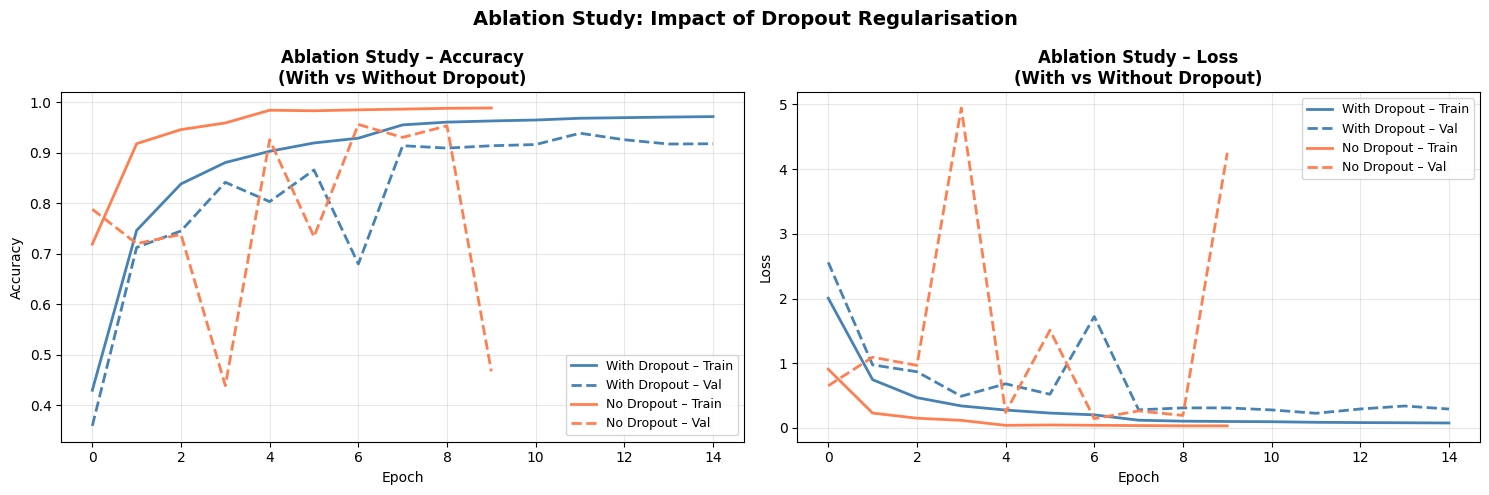

Saved: ablation_study.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history_deep_adam.history['accuracy'],    label='With Dropout – Train', color='steelblue', lw=2)
axes[0].plot(history_deep_adam.history['val_accuracy'],label='With Dropout – Val',   color='steelblue', lw=2, linestyle='--')
axes[0].plot(history_ablation.history['accuracy'],    label='No Dropout – Train',   color='coral',     lw=2)
axes[0].plot(history_ablation.history['val_accuracy'],label='No Dropout – Val',     color='coral',     lw=2, linestyle='--')
axes[0].set_title('Ablation Study – Accuracy\n(With vs Without Dropout)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history_deep_adam.history['loss'],    label='With Dropout – Train', color='steelblue', lw=2)
axes[1].plot(history_deep_adam.history['val_loss'],label='With Dropout – Val',   color='steelblue', lw=2, linestyle='--')
axes[1].plot(history_ablation.history['loss'],    label='No Dropout – Train',   color='coral',     lw=2)
axes[1].plot(history_ablation.history['val_loss'],label='No Dropout – Val',     color='coral',     lw=2, linestyle='--')
axes[1].set_title('Ablation Study – Loss\n(With vs Without Dropout)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('Ablation Study: Impact of Dropout Regularisation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ablation_study.png")

# PART A – SECTION 5: Comparative Analysis
## Baseline vs Deeper Model : Comparison

# Baseline vs Deeper Training Curves Side-by-Side

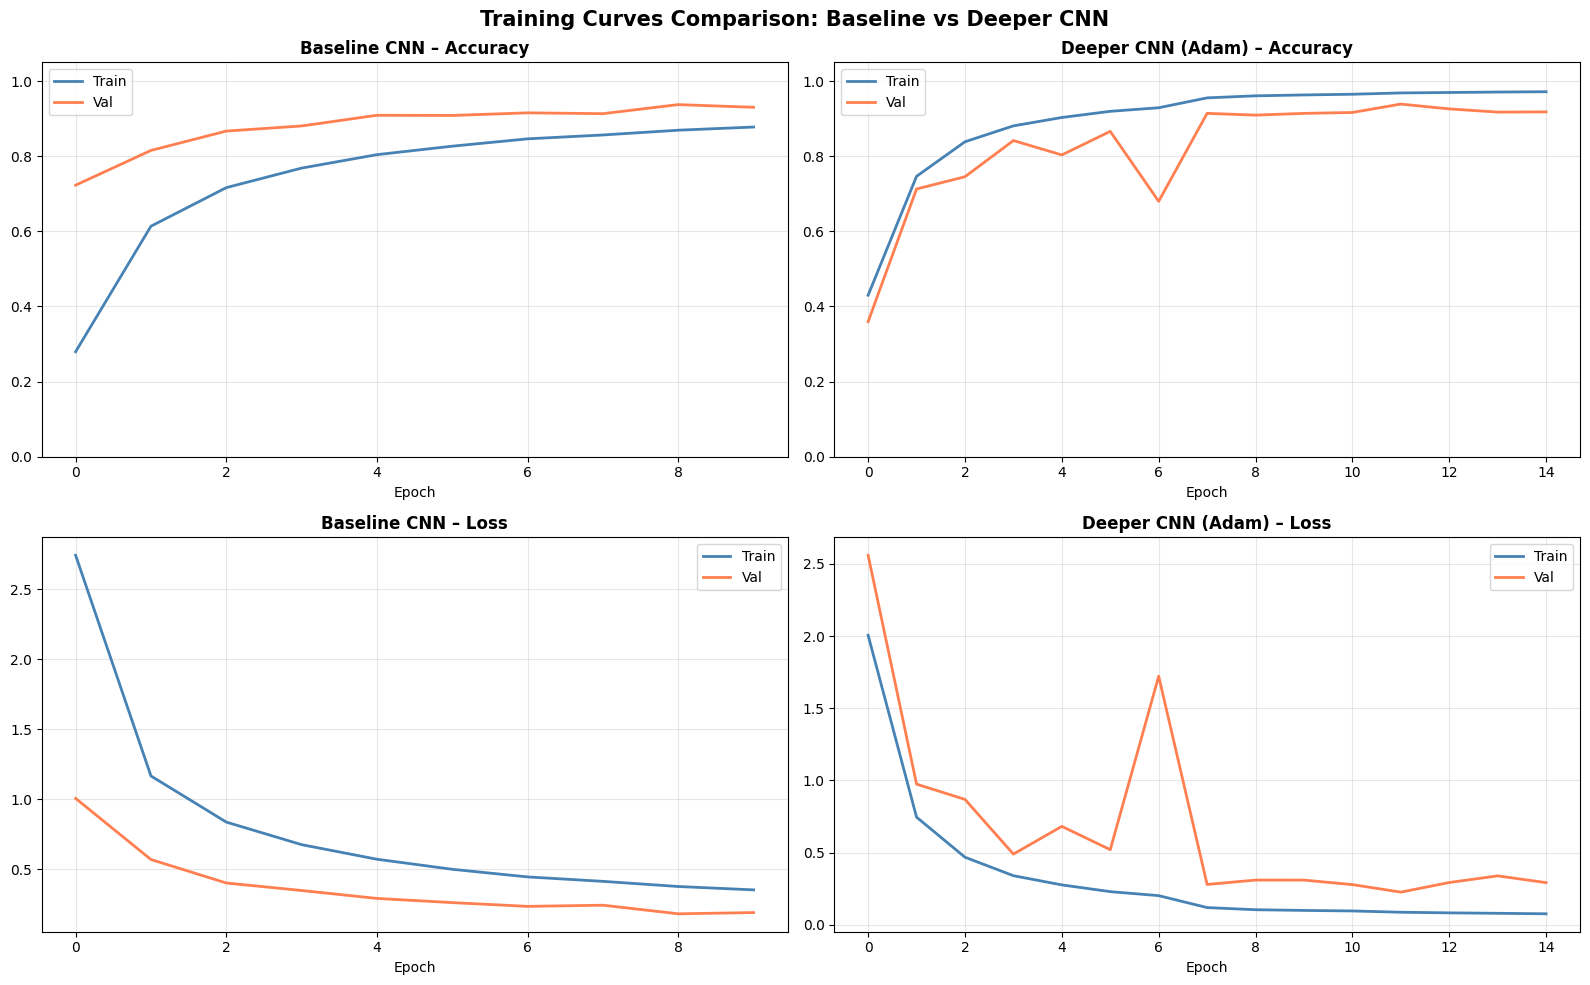

Saved: baseline_vs_deeper_curves.png


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top row: Accuracy
axes[0,0].plot(history_base.history['accuracy'],     label='Train', color='steelblue', lw=2)
axes[0,0].plot(history_base.history['val_accuracy'], label='Val',   color='coral',     lw=2)
axes[0,0].set_title('Baseline CNN – Accuracy', fontweight='bold')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3); axes[0,0].set_ylim(0, 1.05)

axes[0,1].plot(history_deep_adam.history['accuracy'],     label='Train', color='steelblue', lw=2)
axes[0,1].plot(history_deep_adam.history['val_accuracy'], label='Val',   color='coral',     lw=2)
axes[0,1].set_title('Deeper CNN (Adam) – Accuracy', fontweight='bold')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3); axes[0,1].set_ylim(0, 1.05)

# Bottom row: Loss
axes[1,0].plot(history_base.history['loss'],     label='Train', color='steelblue', lw=2)
axes[1,0].plot(history_base.history['val_loss'], label='Val',   color='coral',     lw=2)
axes[1,0].set_title('Baseline CNN – Loss', fontweight='bold')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(history_deep_adam.history['loss'],     label='Train', color='steelblue', lw=2)
axes[1,1].plot(history_deep_adam.history['val_loss'], label='Val',   color='coral',     lw=2)
axes[1,1].set_title('Deeper CNN (Adam) – Loss', fontweight='bold')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

for ax in axes.flatten():
    ax.set_xlabel('Epoch')

plt.suptitle('Training Curves Comparison: Baseline vs Deeper CNN', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_vs_deeper_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: baseline_vs_deeper_curves.png")

# Comprehensive Comparison Table

 PART A – COMPREHENSIVE MODEL COMPARISON TABLE
                Model  Conv Layers Regularisation Optimizer Accuracy Precision Recall F1-Score  Train Time (min)
         Baseline CNN            3        Dropout      Adam   0.9510    0.9556 0.9510   0.9490             96.40
    Deeper CNN (Adam)            6   BN + Dropout      Adam   0.9426    0.9505 0.9426   0.9396            109.51
     Deeper CNN (SGD)            6   BN + Dropout       SGD   0.9497    0.9539 0.9497   0.9466            114.66
Ablation (No Dropout)            6        BN only      Adam   0.9574    0.9598 0.9574   0.9550             73.01


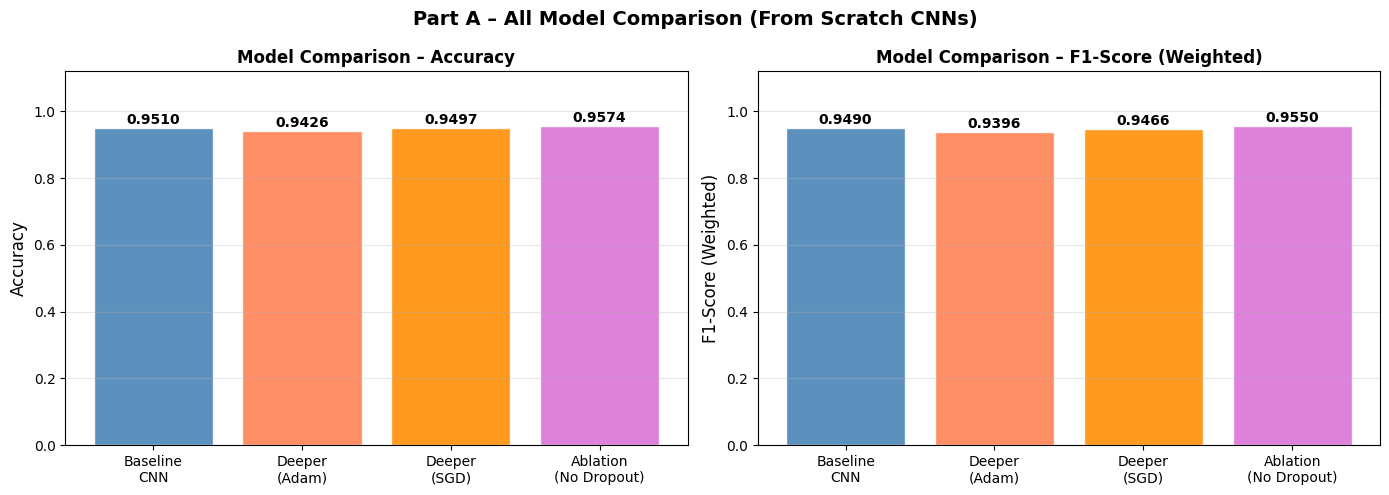

Saved: part_a_comparison.png


In [27]:
comparison_data = {
    'Model':              ['Baseline CNN',
                           'Deeper CNN (Adam)',
                           'Deeper CNN (SGD)',
                           'Ablation (No Dropout)'],
    'Conv Layers':        [3, 6, 6, 6],
    'Regularisation':     ['Dropout', 'BN + Dropout', 'BN + Dropout', 'BN only'],
    'Optimizer':          ['Adam', 'Adam', 'SGD', 'Adam'],
    'Accuracy':           [base_metrics['accuracy'],
                           deep_adam_metrics['accuracy'],
                           deep_sgd_metrics['accuracy'],
                           ablation_metrics['accuracy']],
    'Precision':          [base_metrics['precision'],
                           deep_adam_metrics['precision'],
                           deep_sgd_metrics['precision'],
                           ablation_metrics['precision']],
    'Recall':             [base_metrics['recall'],
                           deep_adam_metrics['recall'],
                           deep_sgd_metrics['recall'],
                           ablation_metrics['recall']],
    'F1-Score':           [base_metrics['f1'],
                           deep_adam_metrics['f1'],
                           deep_sgd_metrics['f1'],
                           ablation_metrics['f1']],
    'Train Time (min)':   [round(base_train_time/60, 2),
                           round(deep_adam_time/60, 2),
                           round(deep_sgd_time/60, 2),
                           round(ablation_time/60, 2)]
}

comp_df = pd.DataFrame(comparison_data)

# Format to 4 decimal places for metrics
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    comp_df[col] = comp_df[col].apply(lambda x: f'{x:.4f}')

print(" PART A – COMPREHENSIVE MODEL COMPARISON TABLE")
print(comp_df.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_names = ['Baseline\nCNN', 'Deeper\n(Adam)', 'Deeper\n(SGD)', 'Ablation\n(No Dropout)']
accs = [base_metrics['accuracy'], deep_adam_metrics['accuracy'],
        deep_sgd_metrics['accuracy'], ablation_metrics['accuracy']]
f1s  = [base_metrics['f1'],       deep_adam_metrics['f1'],
        deep_sgd_metrics['f1'],   ablation_metrics['f1']]
clrs = ['steelblue', 'coral', 'darkorange', 'orchid']

for ax, vals, metric in zip(axes, [accs, f1s], ['Accuracy', 'F1-Score (Weighted)']):
    bars = ax.bar(model_names, vals, color=clrs, edgecolor='white', alpha=0.88)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                f'{b.get_height():.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'Model Comparison – {metric}', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.12)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Part A – All Model Comparison (From Scratch CNNs)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('part_a_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: part_a_comparison.png")

# PART B: Transfer Learning with MobileNetV2

# Transfer Learning Data Generators (224×224)

In [28]:
# MobileNetV2 expects 224x224 input (minimum 96x96)
# We resize from 100x100 to 224x224 for the pre-trained model
TL_IMG_SIZE = (96, 96) 

tl_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=VAL_SPLIT
)
tl_test_datagen = ImageDataGenerator(rescale=1./255)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=32,
    class_mode='categorical', subset='training', seed=SEED
)
tl_val_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=32,
    class_mode='categorical', subset='validation', seed=SEED
)
tl_test_gen = tl_test_datagen.flow_from_directory(
    TEST_DIR, target_size=TL_IMG_SIZE, batch_size=32,
    class_mode='categorical', shuffle=False
)

print(f"TL Training samples   : {tl_train_gen.samples:,}")
print(f"TL Validation samples : {tl_val_gen.samples:,}")
print(f"TL Test samples       : {tl_test_gen.samples:,}")
print(f"Input size for TL     : {TL_IMG_SIZE[0]}×{TL_IMG_SIZE[1]}×3")

Found 108144 images belonging to 257 classes.
Found 26927 images belonging to 257 classes.
Found 45008 images belonging to 257 classes.
TL Training samples   : 108,144
TL Validation samples : 26,927
TL Test samples       : 45,008
Input size for TL     : 96×96×3


# Load MobileNetV2 & Build Transfer Learning Model

In [32]:
# Load MobileNetV2 pre-trained on ImageNet
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,   
    input_shape=(TL_IMG_SIZE[0], TL_IMG_SIZE[1], 3)
)

# Phase 1: Freeze base model
base_model.trainable = False

print(f"MobileNetV2 total layers      : {len(base_model.layers)}")
print(f"Trainable params (frozen base): {sum([tf.size(w).numpy() for w in base_model.trainable_weights])}")

# Build Transfer Learning model
inputs = keras.Input(shape=(TL_IMG_SIZE[0], TL_IMG_SIZE[1], 3))

x = base_model(inputs, training=False)   # BN layers frozen
x = layers.GlobalAveragePooling2D()(x)

# Custom classifier (Dense head)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name='MobileNetV2_TransferLearning')

# Compile
tl_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
tl_model.summary()

# Correct parameter calculations 
total_params = tl_model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in tl_model.trainable_weights])
non_trainable_params = total_params - trainable_params

print("\n Parameter Summary")
print(f"Total params        : {total_params:,}")
print(f"Trainable params    : {trainable_params:,} (only Dense head)")
print(f"Non-trainable params: {non_trainable_params:,} (frozen base)")

MobileNetV2 total layers      : 154
Trainable params (frozen base): 0


Model: "MobileNetV2_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 257)            │        33,153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651,969 (10.12 MB)

 Trainable params: 393,985 (1.50 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


 Parameter Summary
Total params        : 2,651,969
Trainable params    : 393,985 (only Dense head)
Non-trainable params: 2,257,984 (frozen base)


# Phase 1: Feature Extraction Training

In [33]:
tl_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-7, verbose=1)
]

print("PHASE 1 – Feature Extraction (frozen MobileNetV2 base)")
print("Training only the new Dense classification head...")
t_start = time.time()

history_tl_phase1 = tl_model.fit(
    tl_train_gen,
    epochs=5,
    validation_data=tl_val_gen,
    callbacks=tl_callbacks,
    verbose=1
)

tl_phase1_time = time.time() - t_start
print(f"\nPhase 1 completed in {tl_phase1_time/60:.2f} minutes")
print(f"Best Phase 1 val accuracy: {max(history_tl_phase1.history['val_accuracy']):.4f}")

PHASE 1 – Feature Extraction (frozen MobileNetV2 base)
Training only the new Dense classification head...
Epoch 1/5
3380/3380 ━━━━━━━━━━━━━━━━━━━━ 467s 135ms/step - accuracy: 0.3636 - loss: 2.7162 - val_accuracy: 0.8372 - val_loss: 0.5312 - learning_rate: 0.0010
Epoch 2/5
3380/3380 ━━━━━━━━━━━━━━━━━━━━ 450s 133ms/step - accuracy: 0.7205 - loss: 0.8905 - val_accuracy: 0.8629 - val_loss: 0.4159 - learning_rate: 0.0010
Epoch 3/5
3380/3380 ━━━━━━━━━━━━━━━━━━━━ 473s 140ms/step - accuracy: 0.7681 - loss: 0.7288 - val_accuracy: 0.8778 - val_loss: 0.3793 - learning_rate: 0.0010
Epoch 4/5
3380/3380 ━━━━━━━━━━━━━━━━━━━━ 450s 133ms/step - accuracy: 0.7901 - loss: 0.6561 - val_accuracy: 0.8804 - val_loss: 0.3715 - learning_rate: 0.0010
Epoch 5/5
3380/3380 ━━━━━━━━━━━━━━━━━━━━ 430s 127ms/step - accuracy: 0.8005 - loss: 0.6332 - val_accuracy: 0.8882 - val_loss: 0.3396 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.

Phase 1 completed in 37.84 minutes
Best Phase 1 v

# Phase 2: Fine-Tuning (Unfreeze Top Layers)

# Plot Transfer Learning Training Curves

In [36]:
print("PHASE 2 – Fine-Tuning (unfreezing top 30 layers of MobileNetV2)")

# Unfreeze the base model
base_model.trainable = True

# Freeze all layers EXCEPT the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with VERY low learning rate to avoid catastrophic forgetting
tl_model.compile(
    optimizer=Adam(learning_rate=1e-5),   # 100x lower than Phase 1
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable_count = sum([tf.size(w).numpy() for w in tl_model.trainable_weights])
print(f"Trainable parameters (Phase 2): {trainable_count:,}  (top 30 layers + head)")

t_start = time.time()

history_tl_phase2 = tl_model.fit(
    tl_train_gen,
    epochs=EPOCHS_TL,
    validation_data=tl_val_gen,
    callbacks=tl_callbacks,
    verbose=1
)

tl_phase2_time = time.time() - t_start
tl_total_time  = tl_phase1_time + tl_phase2_time

print(f"\nPhase 2 completed in {tl_phase2_time/60:.2f} minutes")
print(f"Total TL training time: {tl_total_time/60:.2f} minutes")

PHASE 2 – Fine-Tuning (unfreezing top 30 layers of MobileNetV2)
Trainable parameters (Phase 2): 1,920,385  (top 30 layers + head)
Epoch 1/10
3380/3380 ━━━━━━━━━━━━━━━━━━━━ 481s 138ms/step - accuracy: 0.3975 - loss: 4.1239 - val_accuracy: 0.8299 - val_loss: 0.5486 - learning_rate: 1.0000e-05
Epoch 2/10
3380/3380 ━━━━━━━━━━━━━━━━━━━━ 446s 132ms/step - accuracy: 0.6708 - loss: 1.1944 - val_accuracy: 0.8729 - val_loss: 0.4019 - learning_rate: 1.0000e-05
Epoch 3/10
3380/3380 ━━━━━━━━━━━━━━━━━━━━ 427s 126ms/step - accuracy: 0.7507 - loss: 0.8403 - val_accuracy: 0.9025 - val_loss: 0.3050 - learning_rate: 1.0000e-05
Epoch 4/10
3380/3380 ━━━━━━━━━━━━━━━━━━━━ 453s 134ms/step - accuracy: 0.7927 - loss: 0.6671 - val_accuracy: 0.9131 - val_loss: 0.2628 - learning_rate: 1.0000e-05
Epoch 5/10
3380/3380 ━━━━━━━━━━━━━━━━━━━━ 498s 147ms/step - accuracy: 0.8168 - loss: 0.5776 - val_accuracy: 0.9250 - val_loss: 0.2315 - learning_rate: 1.0000e-05
Epoch 6/10
3380/3380 ━━━━━━━━━━━━━━━━━━━━ 448s 133ms/step - 

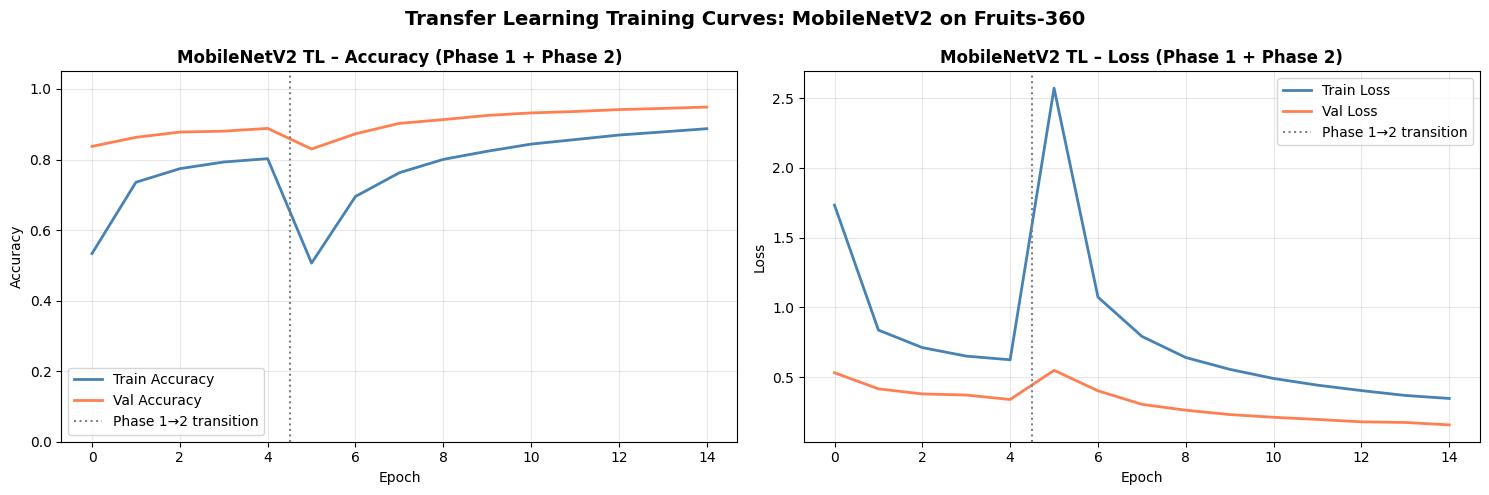

Saved: tl_training_curves.png


In [37]:
# Combine Phase 1 + Phase 2 histories
acc_all     = history_tl_phase1.history['accuracy']     + history_tl_phase2.history['accuracy']
val_acc_all = history_tl_phase1.history['val_accuracy'] + history_tl_phase2.history['val_accuracy']
loss_all    = history_tl_phase1.history['loss']         + history_tl_phase2.history['loss']
val_loss_all= history_tl_phase1.history['val_loss']     + history_tl_phase2.history['val_loss']

phase1_end = len(history_tl_phase1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(acc_all,     label='Train Accuracy', color='steelblue', lw=2)
ax1.plot(val_acc_all, label='Val Accuracy',   color='coral',     lw=2)
ax1.axvline(phase1_end - 0.5, color='gray', linestyle=':', lw=1.5,
            label=f'Phase 1→2 transition')
ax1.set_title('MobileNetV2 TL – Accuracy (Phase 1 + Phase 2)', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_ylim(0, 1.05)

ax2.plot(loss_all,     label='Train Loss', color='steelblue', lw=2)
ax2.plot(val_loss_all, label='Val Loss',   color='coral',     lw=2)
ax2.axvline(phase1_end - 0.5, color='gray', linestyle=':', lw=1.5,
            label=f'Phase 1→2 transition')
ax2.set_title('MobileNetV2 TL – Loss (Phase 1 + Phase 2)', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Transfer Learning Training Curves: MobileNetV2 on Fruits-360',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tl_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tl_training_curves.png")

# Evaluate Transfer Learning Model

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 48s 34ms/step
  MobileNetV2 (Transfer Learning) – Evaluation on Test Set
  Accuracy  : 0.9134  (91.34%)
  Precision : 0.9276  (weighted avg)
  Recall    : 0.9134  (weighted avg)
  F1-Score  : 0.9106  (weighted avg)
Saved: tl_cm.png


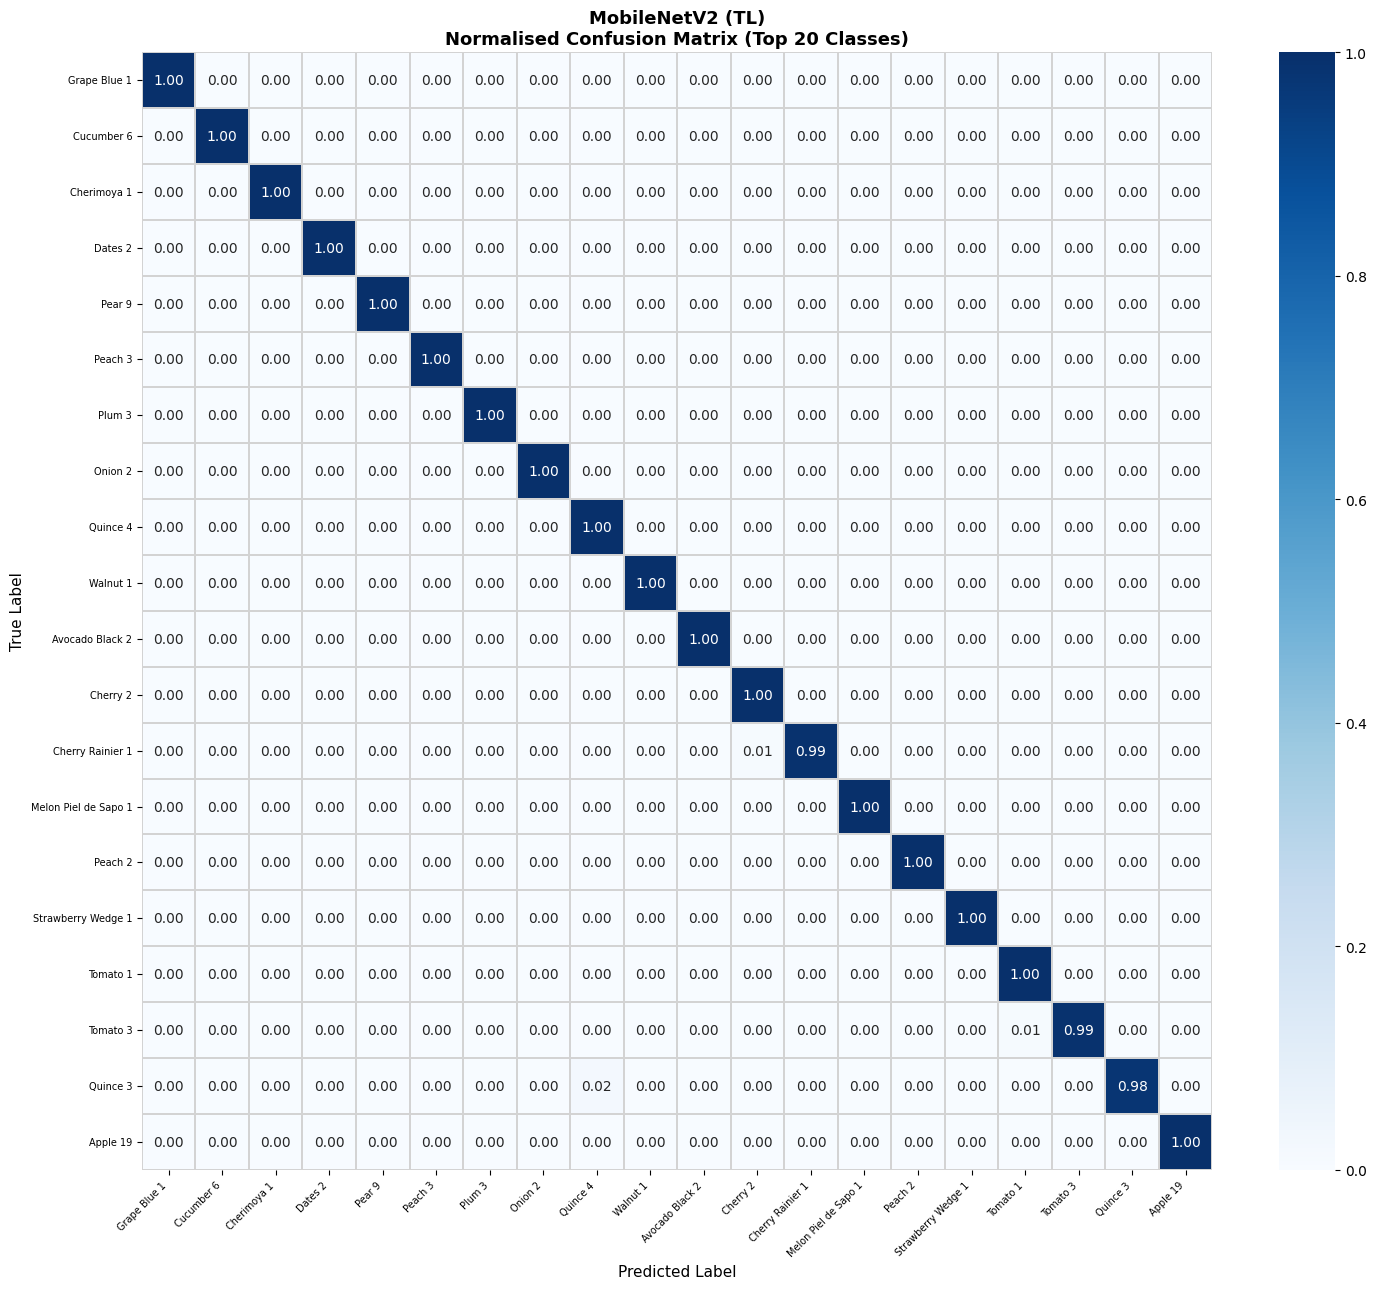

Saved: tl_inference.png


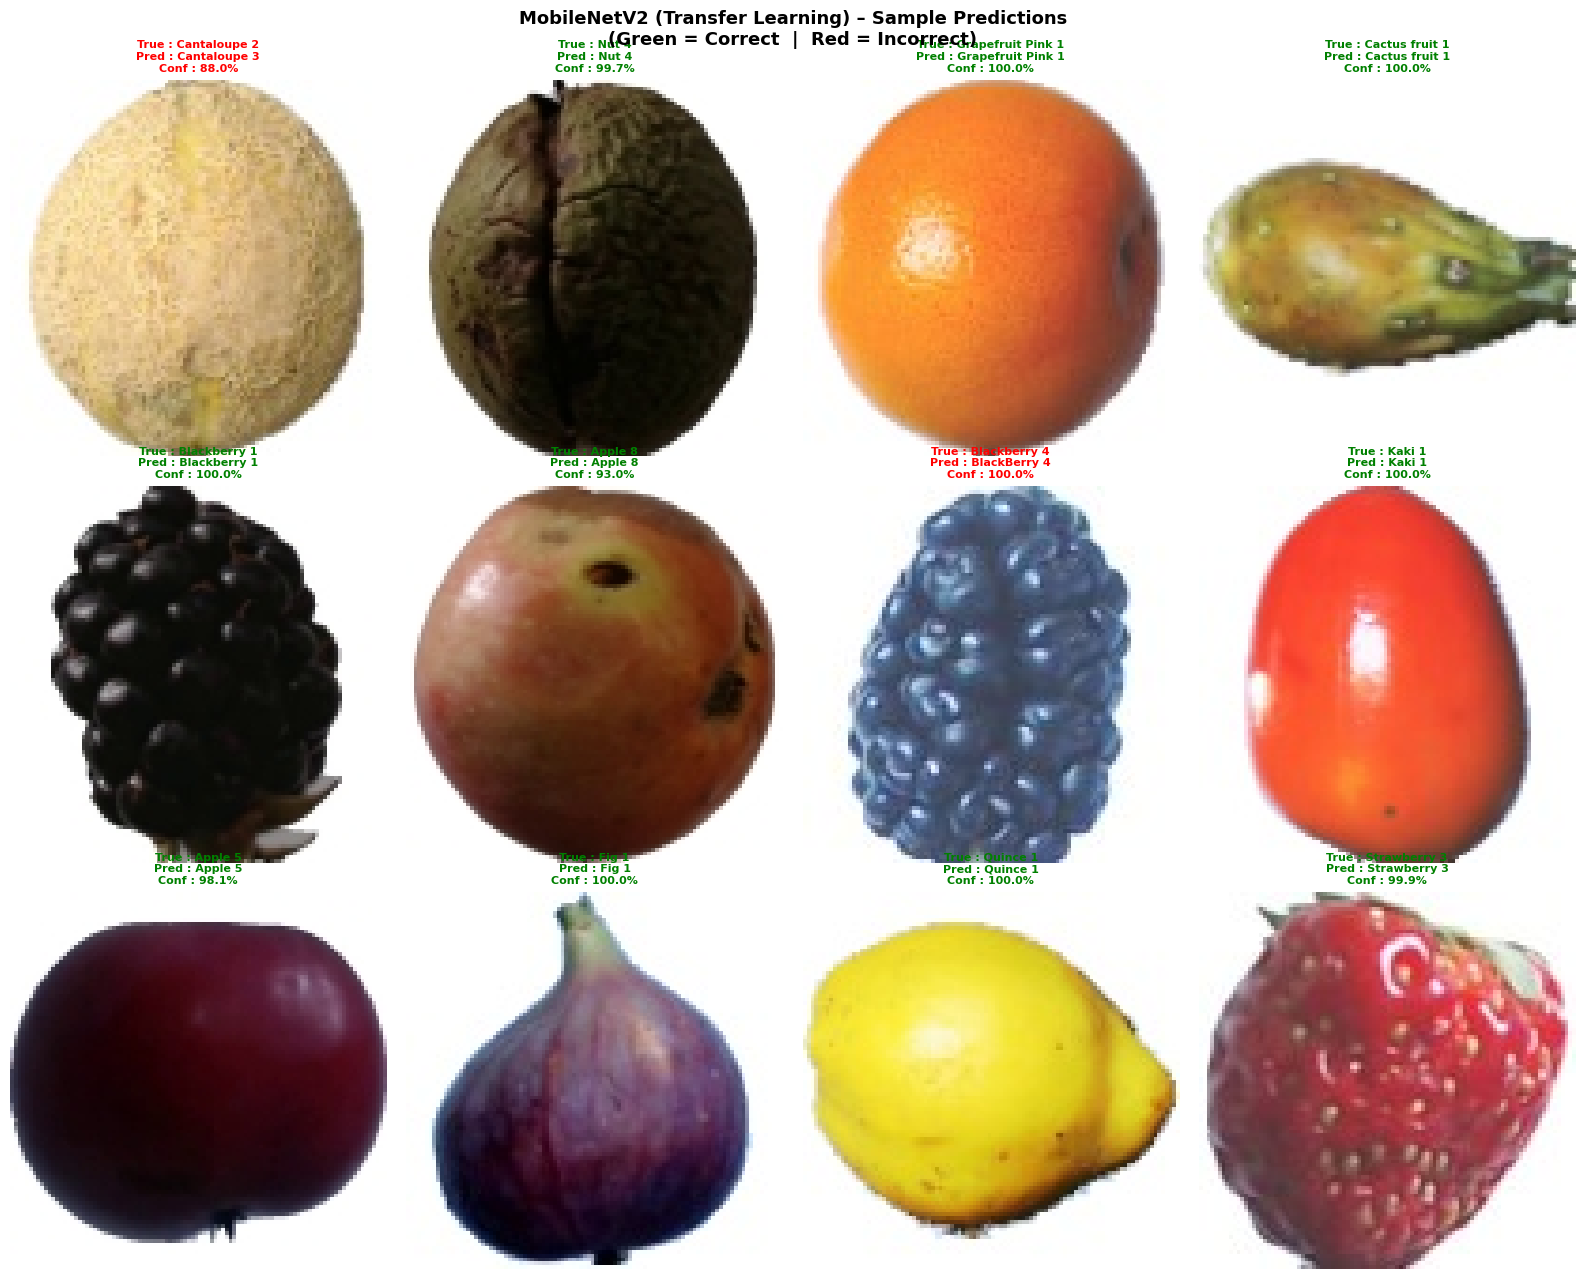


Full Classification Report – MobileNetV2:
                        precision    recall  f1-score   support

             Almonds 1       1.00      1.00      1.00        77
              Apple 10       1.00      0.88      0.93       231
              Apple 11       0.96      0.99      0.98       142
              Apple 12       0.97      0.99      0.98       154
              Apple 13       0.92      1.00      0.96       235
              Apple 14       0.88      0.99      0.93       154
              Apple 17       0.89      0.90      0.90       201
              Apple 18       0.83      0.92      0.87       240
              Apple 19       0.97      1.00      0.99       241
              Apple 20       0.97      0.91      0.94       234
              Apple 21       0.83      0.98      0.90       162
              Apple 22       1.00      0.81      0.89       231
              Apple 23       1.00      0.99      1.00       156
               Apple 5       0.76      1.00      0.86       

In [41]:
tl_metrics = evaluate_model(tl_model, tl_test_gen, 'MobileNetV2 (Transfer Learning)')

plot_confusion_matrix_top(
    tl_metrics['y_true'], tl_metrics['y_pred'],
    CLASS_LABELS, 'MobileNetV2 (TL)',
    top_n=20, save_name='tl_cm.png'
)

inference_model = tf.keras.Sequential([
    tf.keras.layers.Resizing(TL_IMG_SIZE[0], TL_IMG_SIZE[1]),
    tl_model
])

show_inference(
    inference_model, TEST_DIR, CLASS_LABELS,
    'MobileNetV2 (Transfer Learning)',
    save_name='tl_inference.png'
)

print("\nFull Classification Report – MobileNetV2:")
print(classification_report(
    tl_metrics['y_true'], tl_metrics['y_pred'],
    target_names=CLASS_LABELS, zero_division=0
))

# Final Comparison: All Models (Part A + Part B)

 FINAL COMPREHENSIVE COMPARISON – ALL MODELS
                Model Part       Conv Layers Accuracy F1-Score  Train Time (min)
         Baseline CNN    A                 3   0.9510   0.9490             96.40
    Deeper CNN (Adam)    A                 6   0.9426   0.9396            109.51
     Deeper CNN (SGD)    A                 6   0.9497   0.9466            114.66
Ablation (No Dropout)    A                 6   0.9574   0.9550             73.01
     MobileNetV2 (TL)    B 53 (frozen+top30)   0.9134   0.9106            115.29


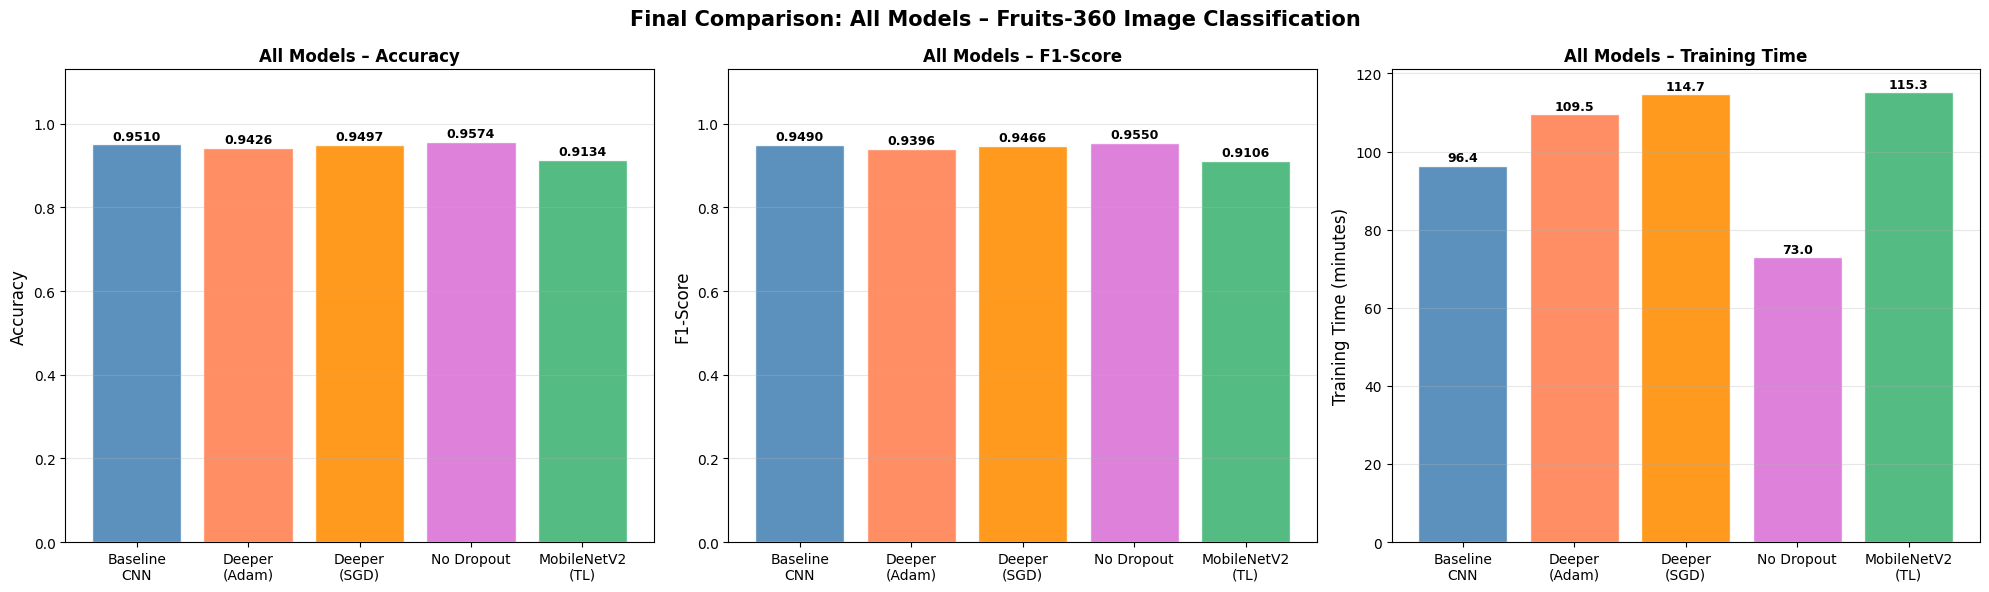

Saved: final_comparison.png


In [42]:
final_data = {
    'Model':              ['Baseline CNN',
                           'Deeper CNN (Adam)',
                           'Deeper CNN (SGD)',
                           'Ablation (No Dropout)',
                           'MobileNetV2 (TL)'],
    'Part':               ['A', 'A', 'A', 'A', 'B'],
    'Conv Layers':        [3, 6, 6, 6, '53 (frozen+top30)'],
    'Accuracy':           [base_metrics['accuracy'],
                           deep_adam_metrics['accuracy'],
                           deep_sgd_metrics['accuracy'],
                           ablation_metrics['accuracy'],
                           tl_metrics['accuracy']],
    'F1-Score':           [base_metrics['f1'],
                           deep_adam_metrics['f1'],
                           deep_sgd_metrics['f1'],
                           ablation_metrics['f1'],
                           tl_metrics['f1']],
    'Train Time (min)':   [round(base_train_time/60, 2),
                           round(deep_adam_time/60, 2),
                           round(deep_sgd_time/60, 2),
                           round(ablation_time/60, 2),
                           round(tl_total_time/60, 2)]
}

final_df = pd.DataFrame(final_data)
for col in ['Accuracy', 'F1-Score']:
    final_df[col] = final_df[col].apply(lambda x: f'{x:.4f}' if isinstance(x, float) else x)

print(" FINAL COMPREHENSIVE COMPARISON – ALL MODELS")
print(final_df.to_string(index=False))

# Visualisation
model_short = ['Baseline\nCNN', 'Deeper\n(Adam)', 'Deeper\n(SGD)', 'No Dropout', 'MobileNetV2\n(TL)']
accs_all = [base_metrics['accuracy'], deep_adam_metrics['accuracy'],
            deep_sgd_metrics['accuracy'], ablation_metrics['accuracy'],
            tl_metrics['accuracy']]
f1s_all  = [base_metrics['f1'], deep_adam_metrics['f1'],
            deep_sgd_metrics['f1'], ablation_metrics['f1'],
            tl_metrics['f1']]
times_all = [base_train_time/60, deep_adam_time/60,
             deep_sgd_time/60,   ablation_time/60,
             tl_total_time/60]

clrs = ['steelblue', 'coral', 'darkorange', 'orchid', 'mediumseagreen']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, vals, metric in zip(axes[:2], [accs_all, f1s_all], ['Accuracy', 'F1-Score']):
    bars = ax.bar(model_short, vals, color=clrs, edgecolor='white', alpha=0.88)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.004,
                f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12); ax.set_ylim(0, 1.13)
    ax.set_title(f'All Models – {metric}', fontweight='bold'); ax.grid(axis='y', alpha=0.3)

bars = axes[2].bar(model_short, times_all, color=clrs, edgecolor='white', alpha=0.88)
for b in bars:
    axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                 f'{b.get_height():.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[2].set_ylabel('Training Time (minutes)', fontsize=12)
axes[2].set_title('All Models – Training Time', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Final Comparison: All Models – Fruits-360 Image Classification',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: final_comparison.png")

# Runtime Summary & Hardware Report


In [45]:
total_runtime = base_train_time + deep_adam_time + deep_sgd_time + ablation_time + tl_total_time

print("  RUNTIME & HARDWARE SUMMARY")
print(f"  Platform                : Kaggle Notebook")
print(f"  GPU                     : {tf.config.list_physical_devices('GPU')}")
print(f"  TensorFlow version      : {tf.__version__}")
print(f"  Dataset                 : Fruits-360 (100×100)")
print(f"  Number of Classes       : {NUM_CLASSES}")
print(f"  Training images         : {train_gen.samples:,}")
print(f"  Validation images       : {val_gen.samples:,}")
print(f"  Test images             : {test_gen.samples:,}")
print(f"  Baseline CNN            : {base_train_time/60:.2f} min  ({EPOCHS_BASE} epochs, Adam)")
print(f"  Deeper CNN (Adam)       : {deep_adam_time/60:.2f} min  ({EPOCHS_DEEP} epochs, Adam)")
print(f"  Deeper CNN (SGD)        : {deep_sgd_time/60:.2f} min  ({EPOCHS_DEEP} epochs, SGD)")
print(f"  Ablation (No Dropout)   : {ablation_time/60:.2f} min  (10 epochs, Adam)")
print(f"  MobileNetV2 (Phase 1)   : {tl_phase1_time/60:.2f} min  (5 epochs, frozen)")
print(f"  MobileNetV2 (Phase 2)   : {tl_phase2_time/60:.2f} min  ({EPOCHS_TL} epochs, fine-tune)")
print(f"  TOTAL RUNTIME           : {total_runtime/60:.2f} minutes")

  RUNTIME & HARDWARE SUMMARY
  Platform                : Kaggle Notebook
  GPU                     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
  TensorFlow version      : 2.19.0
  Dataset                 : Fruits-360 (100×100)
  Number of Classes       : 257
  Training images         : 108,144
  Validation images       : 26,927
  Test images             : 45,008
  Baseline CNN            : 96.40 min  (10 epochs, Adam)
  Deeper CNN (Adam)       : 109.51 min  (15 epochs, Adam)
  Deeper CNN (SGD)        : 114.66 min  (15 epochs, SGD)
  Ablation (No Dropout)   : 73.01 min  (10 epochs, Adam)
  MobileNetV2 (Phase 1)   : 37.84 min  (5 epochs, frozen)
  MobileNetV2 (Phase 2)   : 77.45 min  (10 epochs, fine-tune)
  TOTAL RUNTIME           : 508.88 minutes


# Save All Models

In [51]:
save_dir = '/kaggle/working/'

baseline_model.save('baseline_cnn.keras')
deeper_model_adam.save('deeper_cnn_adam.keras')
deeper_model_sgd.save('deeper_cnn_sgd.keras')
tl_model.save('mobilenetv2_tl.keras')

print("All models saved!")

print("\nSaved files:")
for f in sorted(os.listdir()):
    if f.endswith('.keras') or f.endswith('.png'):
        size_mb = os.path.getsize(f) / (1024*1024)
        print(f"  {f:<40} {size_mb:.2f} MB")

All models saved!

Saved files:
  ablation_study.png                       0.16 MB
  augmentation_examples.png                0.25 MB
  baseline_cm.png                          0.19 MB
  baseline_cnn.keras                       55.88 MB
  baseline_inference.png                   0.39 MB
  baseline_training_curves.png             0.08 MB
  baseline_vs_deeper_curves.png            0.16 MB
  class_distribution.png                   0.17 MB
  deeper_adam_cm.png                       0.19 MB
  deeper_adam_inference.png                0.40 MB
  deeper_cnn_adam.keras                    21.86 MB
  deeper_cnn_sgd.keras                     14.60 MB
  deeper_sgd_cm.png                        0.19 MB
  final_comparison.png                     0.09 MB
  mobilenetv2_tl.keras                     25.36 MB
  optimizer_comparison.png                 0.14 MB
  part_a_comparison.png                    0.07 MB
  pixel_distribution.png                   0.08 MB
  sample_images.png                        0.5